#Preprocessing

#[1] Importing Libraries

In [1]:
import pandas as pd
import ast
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
import statsmodels.api as sm
import math
import time
import pickle

In [2]:
import os

print("Current working directory:", os.getcwd())
print("Files available:")
print(os.listdir())

Current working directory: c:\Users\HP\Desktop\Mini\Parkinson\Model Training
Files available:
['Classification.ipynb', 'full_decision_tree.png', 'preprocessing.pkl', 'Regression.ipynb']


#[2] Loading the dataset

In [3]:
data = pd.read_csv('../Dataset/parkinsons_disease_data_cls.csv')

In [4]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nTarget Distribution:")
print(data['Diagnosis'].value_counts())

Dataset Shape: (2025, 24)

Column Names:
['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'UPDRS', 'MoCA', 'FunctionalAssessment', 'DoctorInCharge', 'WeeklyPhysicalActivity (hr)', 'MedicalHistory', 'Symptoms', 'Diagnosis']

Data Types:
PatientID                        int64
Age                              int64
Gender                             str
Ethnicity                          str
EducationLevel                     str
BMI                            float64
Smoking                            str
AlcoholConsumption             float64
DietQuality                    float64
SleepQuality                   float64
SystolicBP                       int64
DiastolicBP                      int64
CholesterolTotal               float64
CholesterolLDL                 float64
CholesterolHDL       

#**[3] Overview of the Dataset**

- First look at the dataset and the features.

In [5]:
data.head(5)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,DietQuality,SleepQuality,...,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment,DoctorInCharge,WeeklyPhysicalActivity (hr),MedicalHistory,Symptoms,Diagnosis
0,3530,64,Female,Caucasian,NaN,31.243092,No,6.157042,4.331705,6.291197,...,25.542044,237.290807,4.161620,28.626480,5.355055,DrXXXConfid,04:14,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines...",0
1,4848,79,Male,Asian,Higher,32.964518,No,5.192872,5.793078,8.603542,...,23.098051,150.130321,176.220403,20.310768,9.927998,DrXXXConfid,00:59,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines...",0
2,4289,85,Male,Other,NaN,16.092385,No,9.920555,5.442308,8.894049,...,66.076197,66.871417,133.280607,20.614060,5.704308,DrXXXConfid,05:38,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'Yes', 'Rigidity': 'No', 'Bradykine...",1
3,4751,84,Female,Caucasian,High School,39.145792,Yes,18.875195,8.407833,8.300877,...,41.725854,248.163486,155.952027,4.237696,7.250435,DrXXXConfid,05:02,"{'FamilyHistoryParkinsons': 'Yes', 'TraumaticB...","{'Tremor': 'No', 'Rigidity': 'Yes', 'Bradykine...",1
4,4242,59,Male,African American,NaN,15.987603,Yes,2.854129,5.797936,7.714292,...,23.251949,127.747693,49.523001,21.475758,6.119130,DrXXXConfid,00:08,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines...",0


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   PatientID                    2025 non-null   int64  
 1   Age                          2025 non-null   int64  
 2   Gender                       2025 non-null   str    
 3   Ethnicity                    2025 non-null   str    
 4   EducationLevel               1651 non-null   str    
 5   BMI                          2025 non-null   float64
 6   Smoking                      2025 non-null   str    
 7   AlcoholConsumption           2025 non-null   float64
 8   DietQuality                  2025 non-null   float64
 9   SleepQuality                 2025 non-null   float64
 10  SystolicBP                   2025 non-null   int64  
 11  DiastolicBP                  2025 non-null   int64  
 12  CholesterolTotal             2025 non-null   float64
 13  CholesterolLDL               

In [7]:
data.isnull().sum()

PatientID                        0
Age                              0
Gender                           0
Ethnicity                        0
EducationLevel                 374
BMI                              0
Smoking                          0
AlcoholConsumption               0
DietQuality                      0
SleepQuality                     0
SystolicBP                       0
DiastolicBP                      0
CholesterolTotal                 0
CholesterolLDL                   0
CholesterolHDL                   0
CholesterolTriglycerides         0
UPDRS                            0
MoCA                             0
FunctionalAssessment             0
DoctorInCharge                   0
WeeklyPhysicalActivity (hr)      0
MedicalHistory                   0
Symptoms                         0
Diagnosis                        0
dtype: int64

In [8]:
data.describe()

,PatientID,Age,BMI,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment,Diagnosis
count,2025.00000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000
mean,4112.98716,69.652346,27.162397,10.063892,4.896189,7.002411,133.815309,90.197037,226.805594,126.179968,59.613945,222.814905,101.519190,15.027270,4.990583,0.624198
std,608.71494,11.571040,7.222145,5.694348,2.874157,1.751285,26.586488,17.037746,43.717872,43.455005,23.464930,101.819477,56.513180,8.613916,2.935980,0.484449
min,3058.00000,50.000000,15.008333,0.002228,0.000011,4.000497,90.000000,60.000000,150.062698,50.130454,20.027981,50.113604,0.028441,0.021191,0.001505,0.000000
25%,3587.00000,60.000000,20.757513,5.160093,2.446423,5.501449,110.000000,75.000000,189.048799,88.815994,39.399494,132.520174,53.390605,7.469156,2.399154,0.000000
50%,4112.00000,70.000000,27.119731,10.109640,4.788005,6.930472,133.000000,91.000000,228.464785,126.938405,59.182378,222.634972,102.715326,14.849281,4.976213,1.000000
75%,4639.00000,80.000000,33.394469,14.858553,7.340610,8.560994,157.000000,105.000000,264.774192,164.103480,79.473546,311.541704,149.831682,22.530314,7.495758,1.000000
max,5162.00000,89.000000,39.999887,19.988866,9.995864,9.999821,179.000000,119.000000,299.963074,199.985981,99.982265,399.975022,198.953604,29.970107,9.992697,1.000000


#[4] Dropping Unimportant Columns

- PatientId was dropped because all the values are unique, and DoctorInCharge was dropped because all the values were the same.

In [9]:
data.drop(columns=['PatientID', 'DoctorInCharge'], inplace=True)
data.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,...,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment,WeeklyPhysicalActivity (hr),MedicalHistory,Symptoms,Diagnosis
0,64,Female,Caucasian,NaN,31.243092,No,6.157042,4.331705,6.291197,112,...,82.366509,25.542044,237.290807,4.161620,28.626480,5.355055,04:14,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines...",0
1,79,Male,Asian,Higher,32.964518,No,5.192872,5.793078,8.603542,124,...,176.637077,23.098051,150.130321,176.220403,20.310768,9.927998,00:59,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines...",0
2,85,Male,Other,NaN,16.092385,No,9.920555,5.442308,8.894049,97,...,198.444151,66.076197,66.871417,133.280607,20.614060,5.704308,05:38,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'Yes', 'Rigidity': 'No', 'Bradykine...",1
3,84,Female,Caucasian,High School,39.145792,Yes,18.875195,8.407833,8.300877,138,...,134.669056,41.725854,248.163486,155.952027,4.237696,7.250435,05:02,"{'FamilyHistoryParkinsons': 'Yes', 'TraumaticB...","{'Tremor': 'No', 'Rigidity': 'Yes', 'Bradykine...",1
4,59,Male,African American,NaN,15.987603,Yes,2.854129,5.797936,7.714292,169,...,59.598420,23.251949,127.747693,49.523001,21.475758,6.119130,00:08,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines...",0


In [10]:
data.isnull().sum()

Age                              0
Gender                           0
Ethnicity                        0
EducationLevel                 374
BMI                              0
Smoking                          0
AlcoholConsumption               0
DietQuality                      0
SleepQuality                     0
SystolicBP                       0
DiastolicBP                      0
CholesterolTotal                 0
CholesterolLDL                   0
CholesterolHDL                   0
CholesterolTriglycerides         0
UPDRS                            0
MoCA                             0
FunctionalAssessment             0
WeeklyPhysicalActivity (hr)      0
MedicalHistory                   0
Symptoms                         0
Diagnosis                        0
dtype: int64

In [11]:
print(data.dtypes)

Age                              int64
Gender                             str
Ethnicity                          str
EducationLevel                     str
BMI                            float64
Smoking                            str
AlcoholConsumption             float64
DietQuality                    float64
SleepQuality                   float64
SystolicBP                       int64
DiastolicBP                      int64
CholesterolTotal               float64
CholesterolLDL                 float64
CholesterolHDL                 float64
CholesterolTriglycerides       float64
UPDRS                          float64
MoCA                           float64
FunctionalAssessment           float64
WeeklyPhysicalActivity (hr)        str
MedicalHistory                     str
Symptoms                           str
Diagnosis                        int64
dtype: object


In [12]:
print(data['Diagnosis'].value_counts(normalize=True) * 100)

Diagnosis
1    62.419753
0    37.580247
Name: proportion, dtype: float64


In [13]:
data.describe()

,Age,BMI,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment,Diagnosis
count,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000
mean,69.652346,27.162397,10.063892,4.896189,7.002411,133.815309,90.197037,226.805594,126.179968,59.613945,222.814905,101.519190,15.027270,4.990583,0.624198
std,11.571040,7.222145,5.694348,2.874157,1.751285,26.586488,17.037746,43.717872,43.455005,23.464930,101.819477,56.513180,8.613916,2.935980,0.484449
min,50.000000,15.008333,0.002228,0.000011,4.000497,90.000000,60.000000,150.062698,50.130454,20.027981,50.113604,0.028441,0.021191,0.001505,0.000000
25%,60.000000,20.757513,5.160093,2.446423,5.501449,110.000000,75.000000,189.048799,88.815994,39.399494,132.520174,53.390605,7.469156,2.399154,0.000000
50%,70.000000,27.119731,10.109640,4.788005,6.930472,133.000000,91.000000,228.464785,126.938405,59.182378,222.634972,102.715326,14.849281,4.976213,1.000000
75%,80.000000,33.394469,14.858553,7.340610,8.560994,157.000000,105.000000,264.774192,164.103480,79.473546,311.541704,149.831682,22.530314,7.495758,1.000000
max,89.000000,39.999887,19.988866,9.995864,9.999821,179.000000,119.000000,299.963074,199.985981,99.982265,399.975022,198.953604,29.970107,9.992697,1.000000


#[5] Filling missing values

- EducationLevel had null values so we substituted the null values for the mode which was "High School"


In [14]:
mode_value = data['EducationLevel'].mode()[0]
data['EducationLevel'].fillna(mode_value, inplace=True)
print(data['EducationLevel'].mode()[0])

print(data.isnull().sum())

High School
Age                              0
Gender                           0
Ethnicity                        0
EducationLevel                 374
BMI                              0
Smoking                          0
AlcoholConsumption               0
DietQuality                      0
SleepQuality                     0
SystolicBP                       0
DiastolicBP                      0
CholesterolTotal                 0
CholesterolLDL                   0
CholesterolHDL                   0
CholesterolTriglycerides         0
UPDRS                            0
MoCA                             0
FunctionalAssessment             0
WeeklyPhysicalActivity (hr)      0
MedicalHistory                   0
Symptoms                         0
Diagnosis                        0
dtype: int64


#[6] Encoding

## Converting stringified dictionary into columns and encoding them

In [15]:
data['MedicalHistory'] = data['MedicalHistory'].apply(ast.literal_eval)
medical_history_data = pd.json_normalize(data['MedicalHistory'])
medical_history_data = medical_history_data.replace({'Yes': 1, 'No': 0})
data = pd.concat([data.drop(columns=['MedicalHistory']), medical_history_data], axis=1)

data['Symptoms'] = data['Symptoms'].apply(ast.literal_eval)
Symptoms_data = pd.json_normalize(data['Symptoms'])
Symptoms_data = Symptoms_data.replace({'Yes': 1, 'No': 0})
data = pd.concat([data.drop(columns=['Symptoms']), Symptoms_data], axis=1)

##Initializing encoders

In [16]:
le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False)

## One-Hot Encode Ethnicity and Education Level
- One-Hot encoding was used because the order in this case is meaningless.

In [17]:
ethnicity_encoded = ohe.fit_transform(data[['Ethnicity']])
ethnicity_df = pd.DataFrame(ethnicity_encoded, columns=ohe.get_feature_names_out(['Ethnicity']))
data = pd.concat([data.drop(columns=['Ethnicity']), ethnicity_df], axis=1)

education_encoded = ohe.fit_transform(data[['EducationLevel']])
education_df = pd.DataFrame(education_encoded, columns=ohe.get_feature_names_out(['EducationLevel']))
data = pd.concat([data.drop(columns=['EducationLevel']), education_df], axis=1)

##Encoding Gender and Smoking columns using label Encoding

- Label Encoding was used because the values were binary.

In [18]:
cols_to_encode = ['Gender', 'Smoking']
for col in cols_to_encode:
    data[col] = le.fit_transform(data[col])

#[7] Converting the WeeklyPhysicalActivity from String to Minutes

In [19]:
def convert_to_minutes(time_str):
    hours, minutes = map(int, time_str.split(':'))
    return hours * 60 + minutes

data['WeeklyPhysicalActivity (hr)'] = data['WeeklyPhysicalActivity (hr)'].apply(convert_to_minutes)

In [20]:
data.describe()

,Age,Gender,BMI,Smoking,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,...,WeeklyPhysicalActivity (hr),Diagnosis,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Other,EducationLevel_Bachelor's,EducationLevel_High School,EducationLevel_Higher,EducationLevel_nan
count,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,...,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000
mean,69.652346,0.508642,27.162397,0.294815,10.063892,4.896189,7.002411,133.815309,90.197037,226.805594,...,301.129383,0.624198,0.200000,0.095309,0.603457,0.101235,0.312099,0.397531,0.105679,0.184691
std,11.571040,0.500049,7.222145,0.456072,5.694348,2.874157,1.751285,26.586488,17.037746,43.717872,...,173.839128,0.484449,0.400099,0.293713,0.489300,0.301714,0.463464,0.489508,0.307502,0.388143
min,50.000000,0.000000,15.008333,0.000000,0.002228,0.000011,4.000497,90.000000,60.000000,150.062698,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,0.000000,20.757513,0.000000,5.160093,2.446423,5.501449,110.000000,75.000000,189.048799,...,147.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,70.000000,1.000000,27.119731,0.000000,10.109640,4.788005,6.930472,133.000000,91.000000,228.464785,...,302.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,80.000000,1.000000,33.394469,1.000000,14.858553,7.340610,8.560994,157.000000,105.000000,264.774192,...,453.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,89.000000,1.000000,39.999887,1.000000,19.988866,9.995864,9.999821,179.000000,119.000000,299.963074,...,600.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#[8] Exploratory Data Analysis

## Classify columns into categorical and numerical, then detect outliers in numerical columns using the IQR method.

- No outliers were detected

In [21]:
categorical_cols = [
    'Gender', 'Smoking',
    'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension', 'Diabetes',
    'Depression', 'Stroke', 'Tremor', 'Rigidity', 'SleepDisorders', 'Bradykinesia', 'PosturalInstability',
    'SpeechProblems','Constipation','Ethnicity_African American', 'Ethnicity_Asian', 'Ethnicity_Caucasian',
    'Ethnicity_Other','EducationLevel_Bachelor\'s', 'EducationLevel_High School',
    'EducationLevel_Higher'
]

numerical_cols = [col for col in data.columns if col not in categorical_cols if col != 'Diagnosis']
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(f"Outliers in '{col}':")
    print(outliers[[col]])
    print("-" * 40)

Outliers in 'Age':
Empty DataFrame
Columns: [Age]
Index: []
----------------------------------------
Outliers in 'BMI':
Empty DataFrame
Columns: [BMI]
Index: []
----------------------------------------
Outliers in 'AlcoholConsumption':
Empty DataFrame
Columns: [AlcoholConsumption]
Index: []
----------------------------------------
Outliers in 'DietQuality':
Empty DataFrame
Columns: [DietQuality]
Index: []
----------------------------------------
Outliers in 'SleepQuality':
Empty DataFrame
Columns: [SleepQuality]
Index: []
----------------------------------------
Outliers in 'SystolicBP':
Empty DataFrame
Columns: [SystolicBP]
Index: []
----------------------------------------
Outliers in 'DiastolicBP':
Empty DataFrame
Columns: [DiastolicBP]
Index: []
----------------------------------------
Outliers in 'CholesterolTotal':
Empty DataFrame
Columns: [CholesterolTotal]
Index: []
----------------------------------------
Outliers in 'CholesterolLDL':
Empty DataFrame
Columns: [CholesterolLDL]


## Plot all columns: use count plots for categorical features and box plots for numerical features.

- No outliers were detected in the data.
- No skewness was detected in the data.

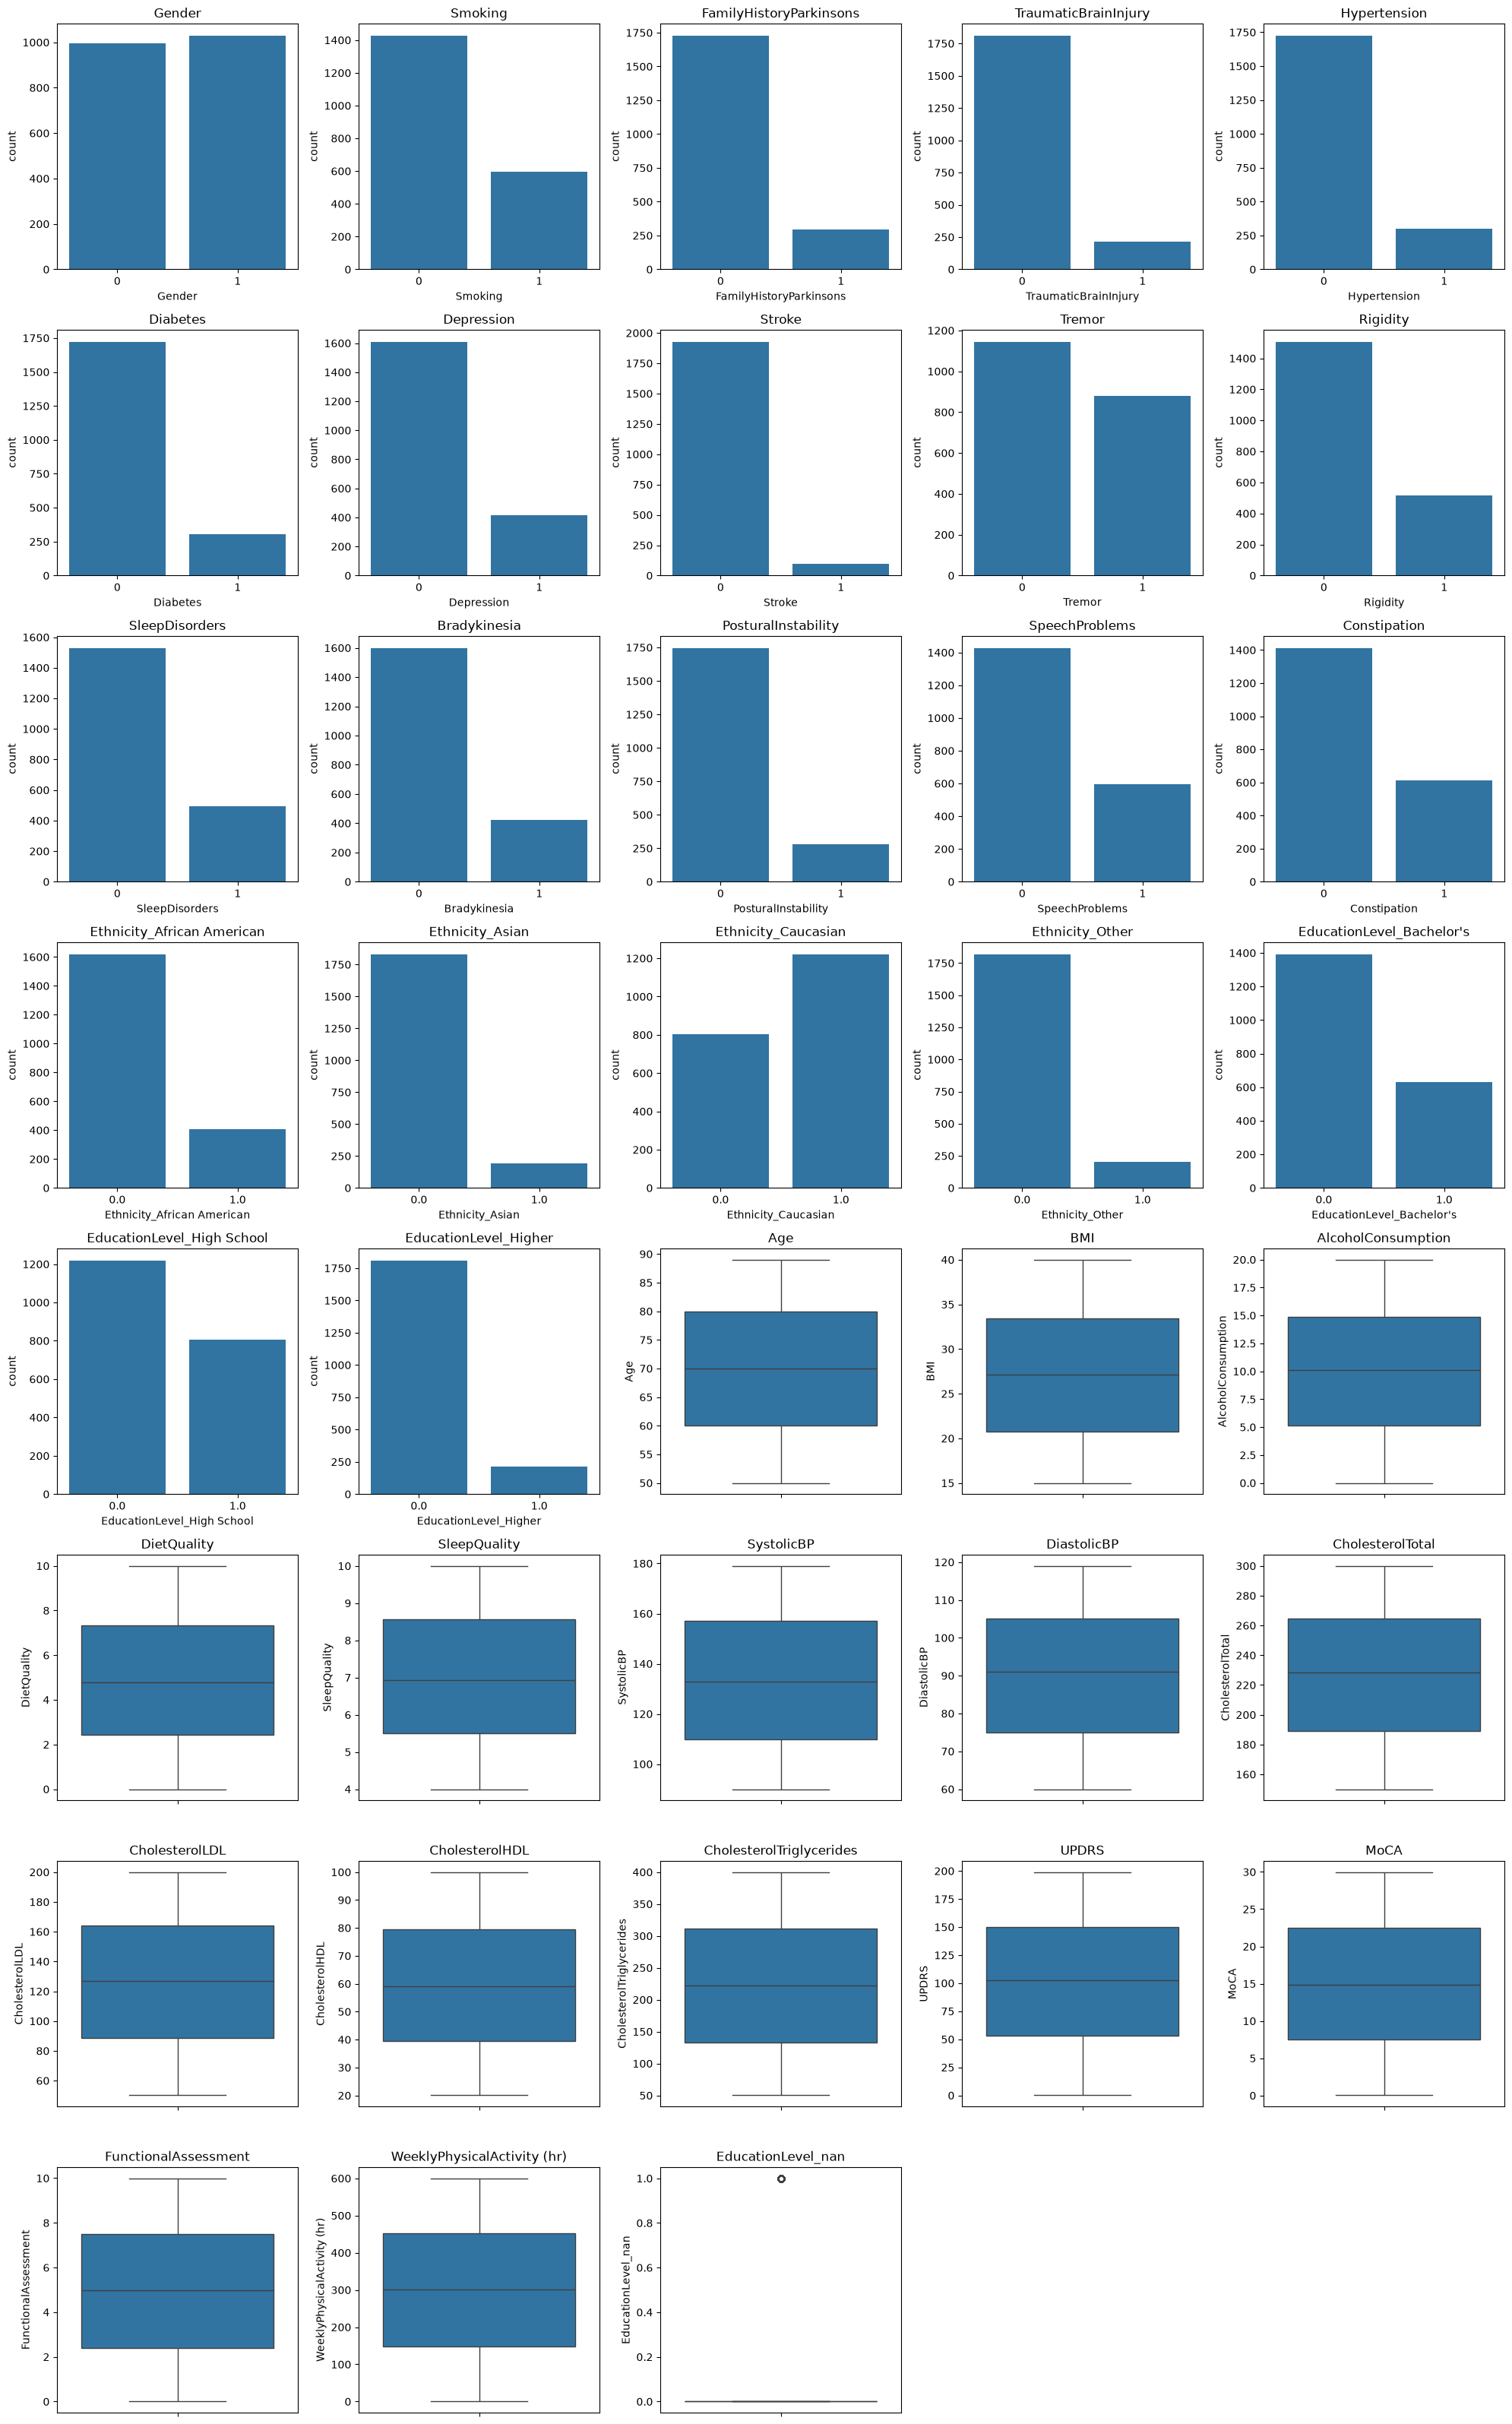

In [22]:
all_cols = categorical_cols + numerical_cols
cols = 5
rows = math.ceil(len(all_cols) / cols)
fig, ax = plt.subplots(ncols=cols, nrows=rows, figsize=(cols * 4, rows * 4))
ax = ax.flatten()
for i, col in enumerate(all_cols):
    if col in categorical_cols:
        sns.countplot(x=col, data=data, ax=ax[i])
    else:
        sns.boxplot(y=col, data=data, ax=ax[i])
    ax[i].set_title(col)
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()


##Checking the sckewness of the data

- No skewness was detected in the data.

In [23]:
print(data[numerical_cols].skew())

Age                           -0.040099
BMI                            0.043673
AlcoholConsumption            -0.025000
DietQuality                    0.044134
SleepQuality                   0.003787
SystolicBP                     0.023093
DiastolicBP                   -0.057249
CholesterolTotal              -0.052316
CholesterolLDL                -0.022570
CholesterolHDL                 0.006291
CholesterolTriglycerides       0.021174
UPDRS                         -0.051532
MoCA                          -0.011829
FunctionalAssessment           0.014744
WeeklyPhysicalActivity (hr)    0.024608
EducationLevel_nan             1.626310
dtype: float64


##Visualizing data using histogram

- Not Normally distributed data.

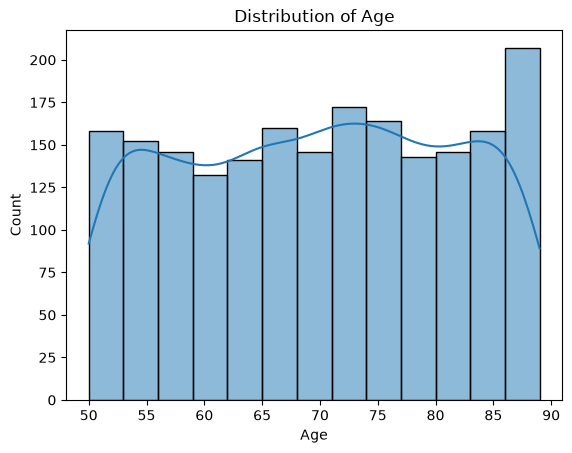

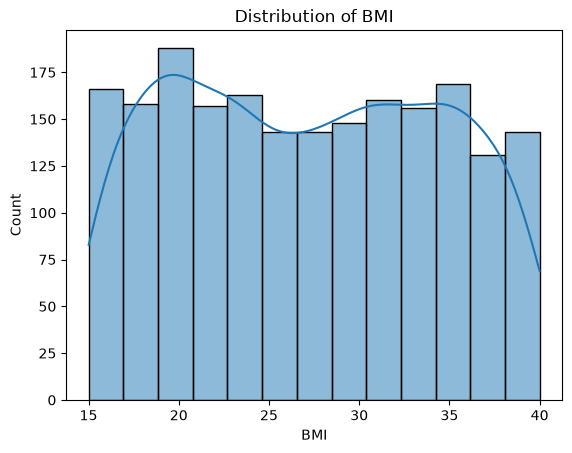

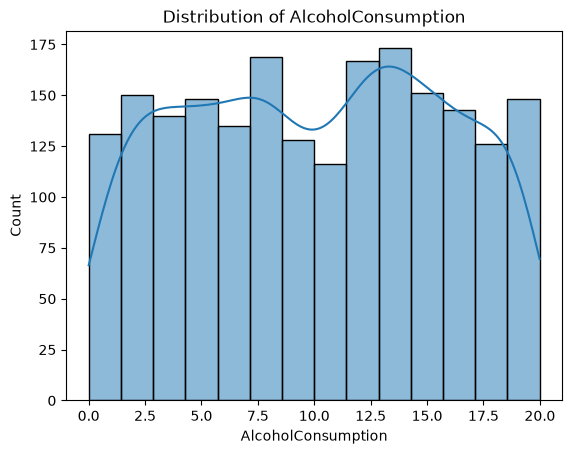

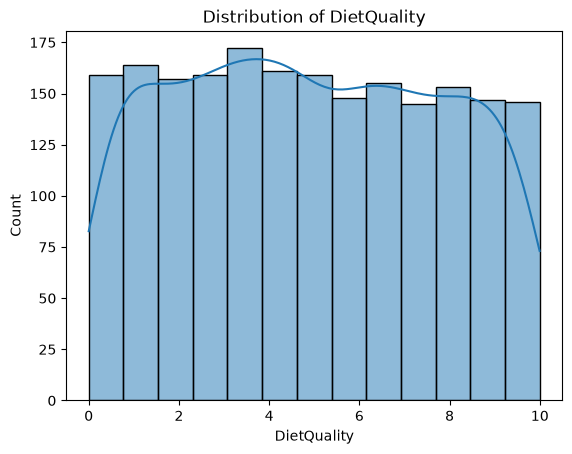

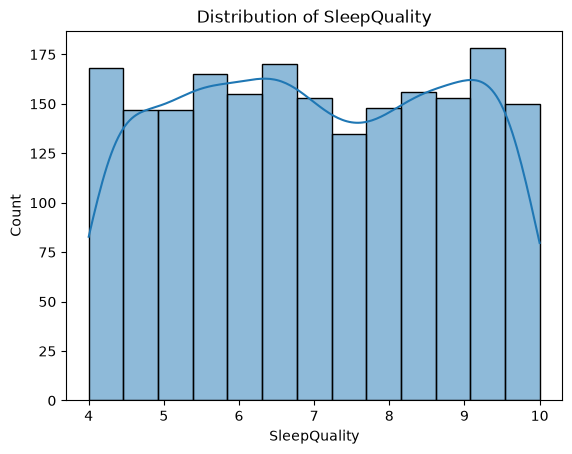

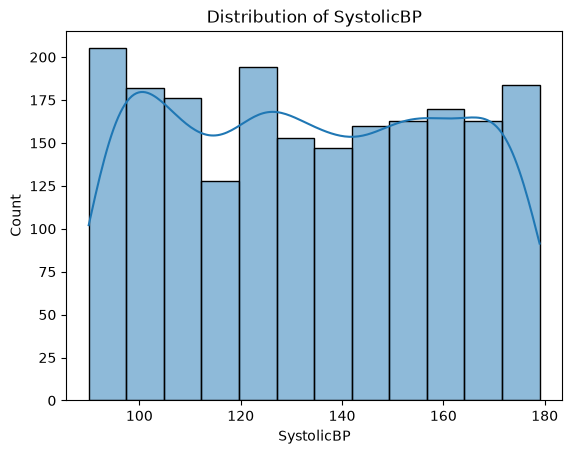

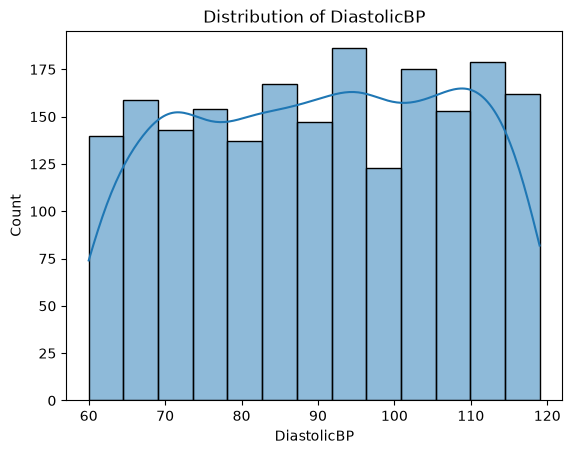

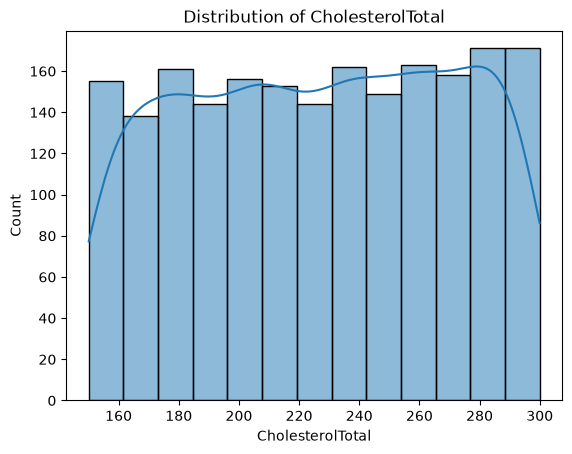

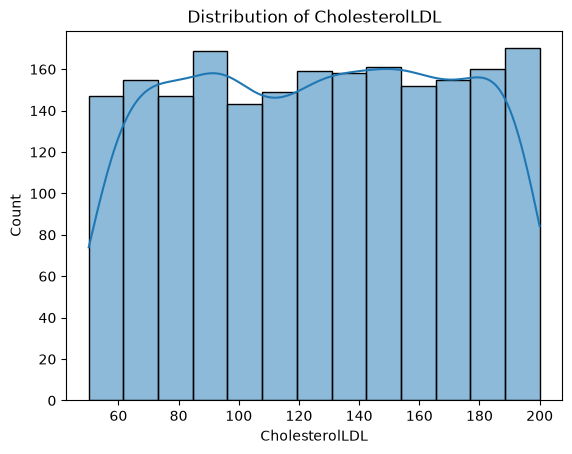

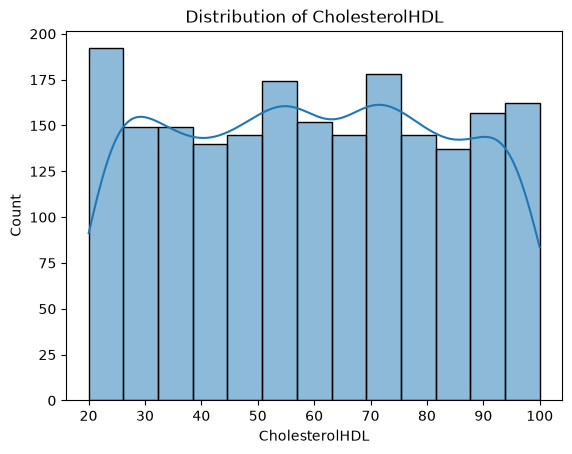

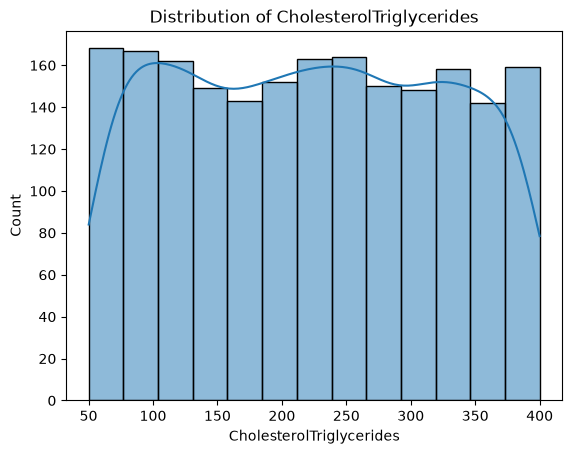

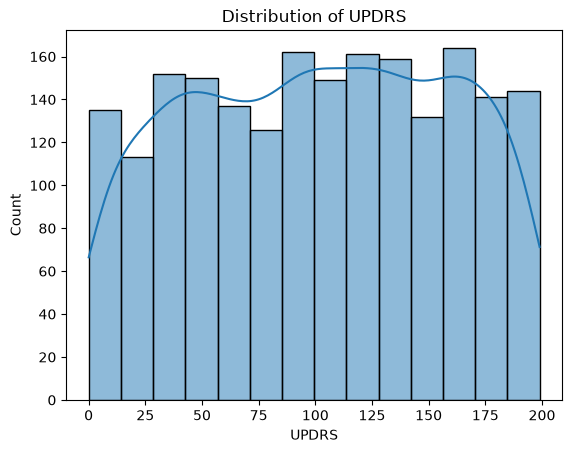

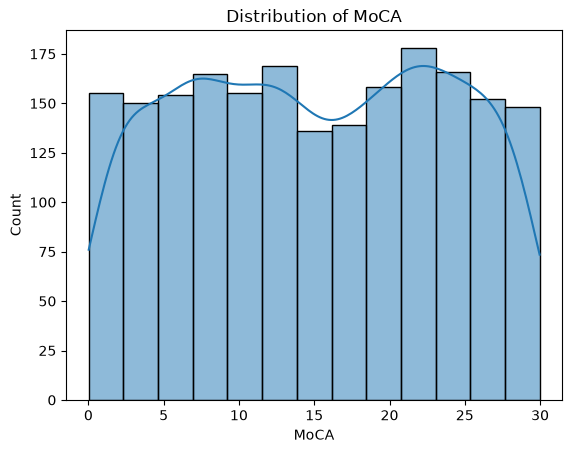

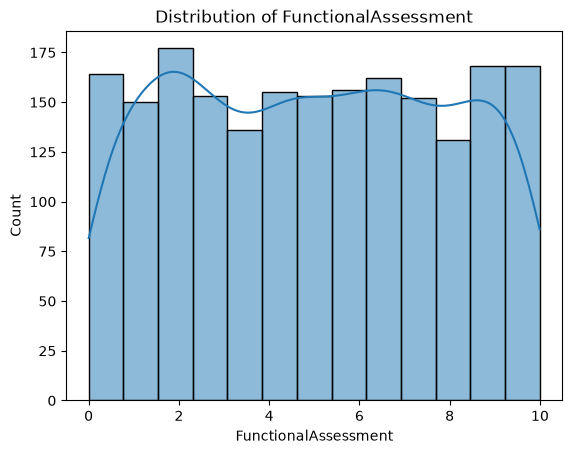

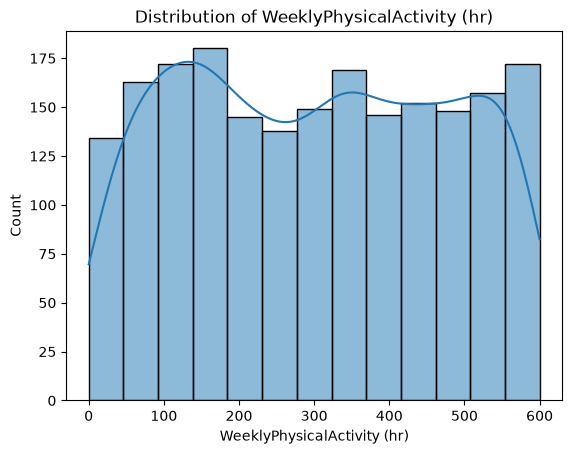

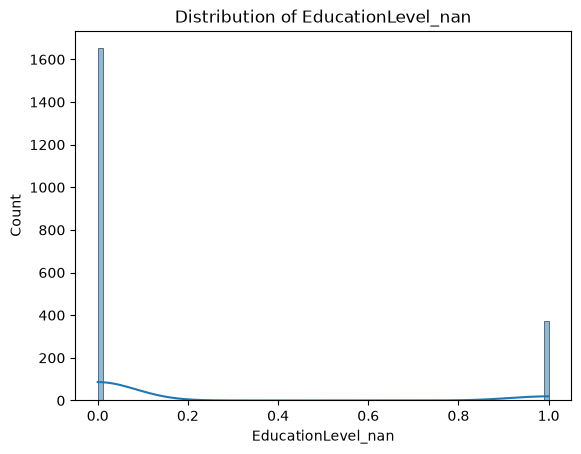

In [24]:
for col in numerical_cols:
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

##Checking Multicollinearity using Correlation Matrix

- No collinearity was detected in the features.

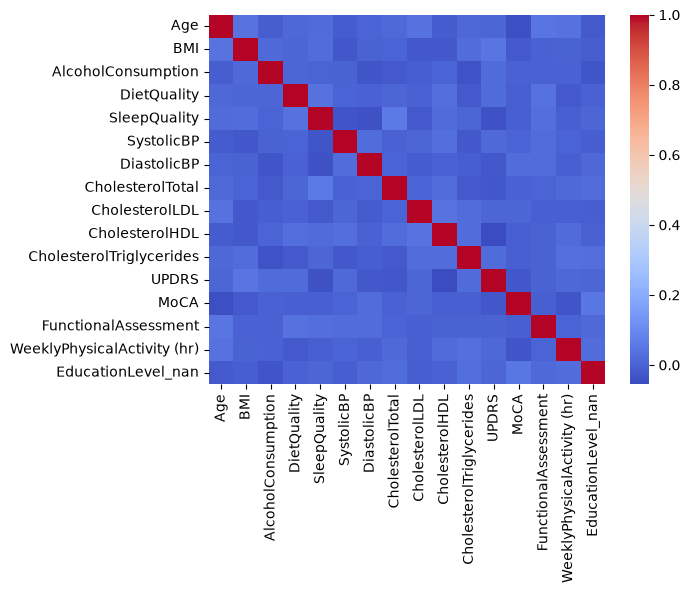

In [25]:
corr_matrix = data[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.show()

#[9] Preparing Data for Modeling.

## Separate features and target variable


In [26]:
X=data.drop(columns=['Diagnosis'])
y=data['Diagnosis']

## Split the data into training and testing sets


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling the numerical features

- MinMaxScaler was used because as seen above the data was not normally distributed.


In [28]:
scaler = MinMaxScaler()

scaler.fit(X_train[numerical_cols])
X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

#[10] Feature Selection

## Select top 20 features using RandomForestRegressor for Classification

We used RandomForestRegressorn to select the top 20 features most correlated with the target y. Features were ranked by their importance, and the 20 highest-scoring features were retained.


In [29]:

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
top_features = importance_df.head(20)

## Feature Selection Visualization  
The bar chart below highlights the most relevant features based on their statistical correlation with the target variable.

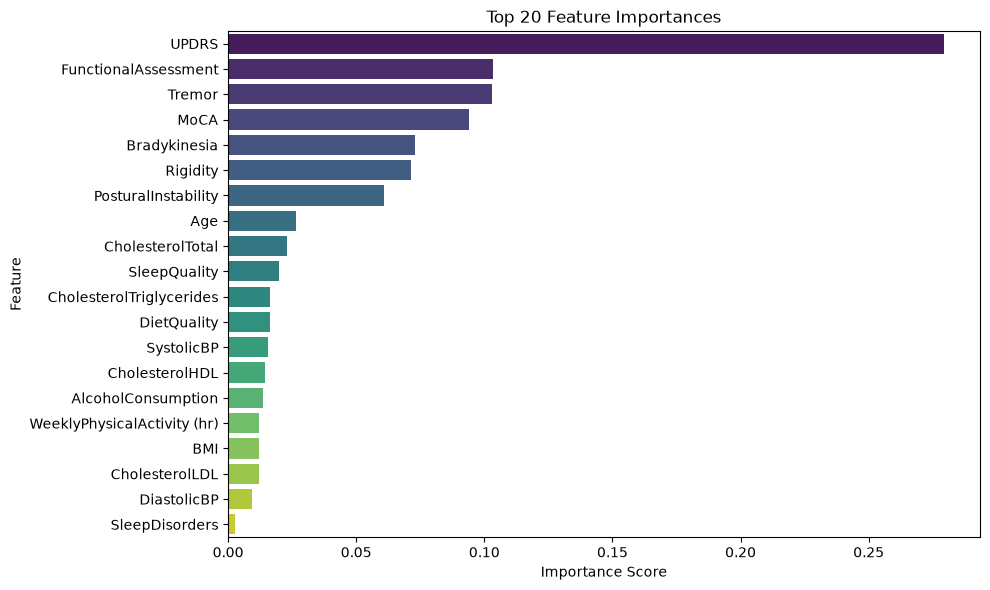

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Top 6 Most Important Features

Based on the feature selection analysis and visualization, the following six features demonstrated the highest relevance to the target variable. These were identified using univariate linear regression tests (f-regression) and are considered the most predictive inputs in the dataset.


In [31]:
top_6_features = importance_df.head(6)
print(top_6_features)

                 Feature  Importance
13                 UPDRS    0.279471
15  FunctionalAssessment    0.103432
23                Tremor    0.103182
14                  MoCA    0.094140
25          Bradykinesia    0.072998
24              Rigidity    0.071511


In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import joblib
import os

# ============================================================
# FINAL MODEL USING ONLY SELECTED FEATURES
# ============================================================

selected_features = [
    'UPDRS',
    'FunctionalAssessment',
    'Tremor',
    'MoCA',
    'Bradykinesia',
    'Rigidity'
]

# Make sure only the selected features are used
X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

# ============================================================
# TRAIN FINAL RANDOM FOREST
# ============================================================

final_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42
)

final_rf.fit(X_train_final, y_train)

# ============================================================
# PREDICTION
# ============================================================

y_pred = final_rf.predict(X_test_final)

print("\nFinal Random Forest")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

# ============================================================
# ROC-AUC
# ============================================================

y_prob = final_rf.predict_proba(X_test_final)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("Test ROC-AUC:", auc)

# ============================================================
# SAVE MODEL
# ============================================================

os.makedirs("saved_model", exist_ok=True)

joblib.dump(
    final_rf,
    "saved_model/final_rf.pkl"
)

joblib.dump(
    selected_features,
    "saved_model/selected_features.pkl"
)

print("\nFinal model saved successfully!")
print("Model features:", final_rf.feature_names_in_)

Training shape: (2056, 6)
Testing shape: (405, 6)

Final Random Forest
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       169
           1       0.94      0.93      0.93       236

    accuracy                           0.92       405
   macro avg       0.92      0.92      0.92       405
weighted avg       0.92      0.92      0.92       405

Test Accuracy: 0.9209876543209876
Test ROC-AUC: 0.9439374185136897

Final model saved successfully!
Model features: ['UPDRS' 'FunctionalAssessment' 'Tremor' 'MoCA' 'Bradykinesia' 'Rigidity']


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
acc_after = accuracy_score(y_test, y_pred1)
acc_after

0.8148148148148148

In [33]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.87      0.89       169
           1       0.91      0.94      0.93       236

    accuracy                           0.91       405
   macro avg       0.91      0.91      0.91       405
weighted avg       0.91      0.91      0.91       405



#[11] Handling unbalanced dataset

- Class 0: 169 samples

- Class 1: 236 samples

To address this imbalance, we applied SMOTE (Synthetic Minority Over-sampling Technique) to increase the number of Class 0 samples to match Class 1 (from 169 to 236).

We chose **SMOTE** because:

- It helps the model learn better representations of the minority class.

- It avoids simply duplicating samples and instead generates synthetic, diverse examples.

After applying SMOTE, we observed an increase in recall, which means the model became more sensitive to correctly identifying instances of the minority class.

This confirms that oversampling using SMOTE was an effective strategy for improving the model's performance on this unbalanced dataset.



In [34]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [35]:
model_rf_smote = RandomForestClassifier(random_state=42)
model_rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = model_rf_smote.predict(X_test)
print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       169
           1       0.92      0.95      0.93       236

    accuracy                           0.92       405
   macro avg       0.92      0.92      0.92       405
weighted avg       0.92      0.92      0.92       405



In [36]:
model2 = LogisticRegression()
model2.fit(X_train_smote, y_train_smote)
y_pred2 = model2.predict(X_test)

acc_after = accuracy_score(y_test, y_pred2)
acc_after


0.8074074074074075

#Modelling

### Implementing Classification Models
- Choose and implement different classification models such as SVM, logistic regression..etc
- Improve model using grid search, random search and K cross validation.
- Evaluate the performance of each classifier using metric accuracy.


#[1] Ensemble Learning


##Stacking Classifier

In [37]:
base_models = [
    ('rf', RandomForestClassifier()),
    ('gb', GradientBoostingClassifier()),
    ('pa', PassiveAggressiveClassifier())
]

stacking_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

start_train = time.time()
stacking_model.fit(X_train[top_6_features['Feature']], y_train)
end_train = time.time()
stack_train_time = end_train - start_train
print(f"\n Total Stacking Training Time: {stack_train_time:.4f} seconds")

start_test = time.time()
y_pred = stacking_model.predict(X_test[top_6_features['Feature']])
end_test = time.time()
stack_test_time = end_test - start_test
print(f"\n Total Stacking Test Time: {stack_test_time:.4f} seconds")

y_train_pred = stacking_model.predict(X_train[top_6_features['Feature']])

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")


 Total Stacking Training Time: 6.0325 seconds

 Total Stacking Test Time: 0.0432 seconds
Training Accuracy: 0.9500
Testing Accuracy: 0.9160


##Voting Classifier

In [38]:
voting_model = VotingClassifier(estimators=base_models)
start_train = time.time()
voting_model.fit(X_train[top_6_features['Feature']], y_train)
end_train = time.time()
Vote_train_time = end_train - start_train
print(f"\n⏱ Total Voting Training Time: {Vote_train_time:.4f} seconds")

start_test = time.time()
y_pred = voting_model.predict(X_test[top_6_features['Feature']])
end_test = time.time()
Voting_test_time = end_test - start_test
print(f"\n⏱ Total Voting Test Time: {Voting_test_time:.4f} seconds")

y_train_pred = voting_model.predict(X_train[top_6_features['Feature']])

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")


⏱ Total Voting Training Time: 1.1024 seconds

⏱ Total Voting Test Time: 0.0405 seconds
Training Accuracy: 0.9506
Testing Accuracy: 0.9136


#[2] Decision tree classifier
 ### Tuning hyper paramters
- max_depth :
This hyperparameter determines the maximum depth of the decision tree

- min_samples_split :
This hyperparameter determines the minimum number of samples required to split an internal node during the construction of the decision tree

In [39]:
print(X_train_smote.columns)

Index(['Age', 'Gender', 'BMI', 'Smoking', 'AlcoholConsumption', 'DietQuality',
       'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'UPDRS',
       'MoCA', 'FunctionalAssessment', 'WeeklyPhysicalActivity (hr)',
       'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension',
       'Diabetes', 'Depression', 'Stroke', 'Tremor', 'Rigidity',
       'Bradykinesia', 'PosturalInstability', 'SpeechProblems',
       'SleepDisorders', 'Constipation', 'Ethnicity_African American',
       'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Other',
       'EducationLevel_Bachelor's', 'EducationLevel_High School',
       'EducationLevel_Higher', 'EducationLevel_nan'],
      dtype='str')


- Vary max depth while keeping all other parameters with their default value.

In [40]:
X_train_selected = X_train_smote[['UPDRS','FunctionalAssessment','Tremor', 'MoCA', 'Bradykinesia','Rigidity']]
X_test_selected = X_test[['UPDRS','FunctionalAssessment','Tremor', 'MoCA', 'Bradykinesia','Rigidity']]

# X_train_smote = X_train_smote[['UPDRS']]
# X_test = X_test[['UPDRS']]

Max Depth  Train Accuracy  Test Accuracy  
----------------------------------------
2          0.7155          0.6889         
5          0.8959          0.8914         
10         0.9577          0.8889         


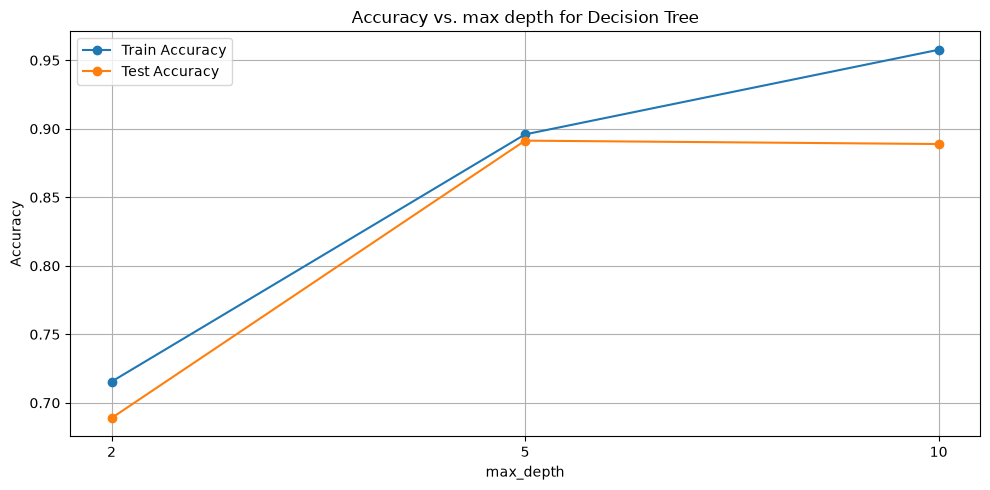

In [41]:
from sklearn.tree import DecisionTreeClassifier
max_depth_values = [2,5,10]

print(f"{'Max Depth':<10} {'Train Accuracy':<15} {'Test Accuracy':<15}")
print("-" * 40)

train_accuracy = []
test_accuracy = []

for depth in max_depth_values:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train_selected, y_train_smote)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    acc_train = accuracy_score(y_train_smote, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    train_accuracy.append(acc_train)
    test_accuracy.append(acc_test)

    print(f"{depth:<10} {acc_train:<15.4f} {acc_test:<15.4f}")

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in max_depth_values], train_accuracy, label="Train Accuracy", marker='o')
plt.plot([str(d) for d in max_depth_values], test_accuracy, label="Test Accuracy", marker='o')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. max depth for Decision Tree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


so the best value for max depth is 5, as test accuracy is highest and test and train accuracy are close

- Vary min_samples_split while keeping all other parameters with their default value and max depth = 5.

Min sample split Train Accuracy  Test Accuracy  
----------------------------------------
3               0.8959          0.8914         
10              0.8954          0.8914         
15              0.8949          0.8864         


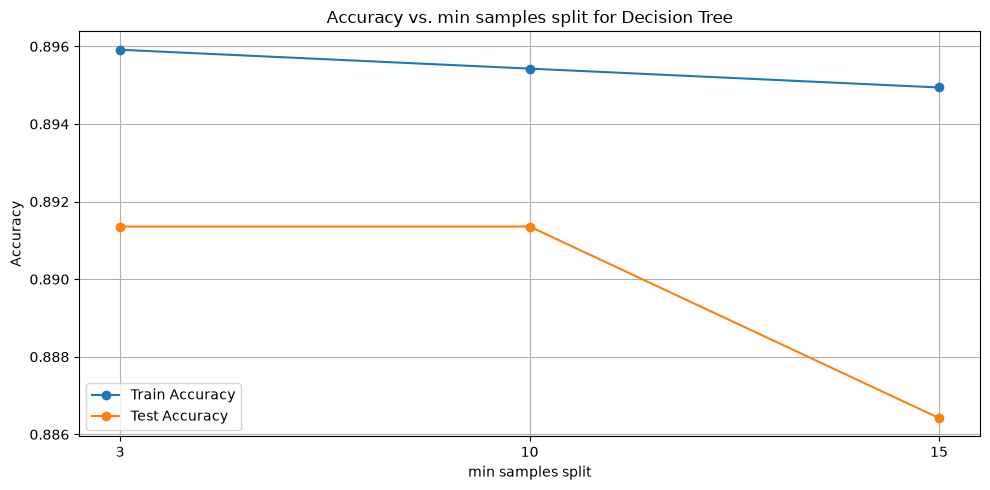

In [42]:
min_samples_split = [3,10,15]

print(f"{'Min sample split':<15} {'Train Accuracy':<15} {'Test Accuracy':<15}")
print("-" * 40)

train_accuracy = []
test_accuracy = []

for split in min_samples_split:
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split = split,
        random_state=42
    )
    model.fit(X_train_selected, y_train_smote)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    acc_train = accuracy_score(y_train_smote, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    train_accuracy.append(acc_train)
    test_accuracy.append(acc_test)

    print(f"{split:<15} {acc_train:<15.4f} {acc_test:<15.4f}")

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in min_samples_split], train_accuracy, label="Train Accuracy", marker='o')
plt.plot([str(d) for d in min_samples_split], test_accuracy, label="Test Accuracy", marker='o')
plt.xlabel("min samples split")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. min samples split for Decision Tree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


So the best value for min samples split is 10

Best tree with max depth = 5 and min samples split = 10 gave us:

Train accuracy: 0.8945

Test accuracy: 0.8889   

### Hyperparameter tuning using grid search

In [43]:
from sklearn.model_selection import GridSearchCV

DT = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}
GS =  GridSearchCV(
    estimator=DT,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
GS.fit(X_train_selected, y_train_smote)

best_params = GS.best_params_
print("Best Hyperparameters:", best_params)

best_model = GS.best_estimator_
y_pred_test = best_model.predict(X_test_selected)
y_pred_train = best_model.predict(X_train_selected)

acc_train = accuracy_score(y_train_smote, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print("average validation accuracy:", f"{GS.best_score_:.4f}")
print("train accuracy: ", f"{acc_train:.4f}")
print("test accuracy: ", f"{acc_test:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Hyperparameters: {'max_depth': 6, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
average validation accuracy: 0.8886
train accuracy:  0.9095
test accuracy:  0.9062


Best Hyperparameters: {'max_depth': 6, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Average validation accuracy: 0.8833

Train accuracy:  0.9066

Test accuracy:  0.9012




In [44]:

model = DecisionTreeClassifier(max_depth= 6, max_features= None, min_samples_leaf= 4, min_samples_split= 2)
start_fit_time_DT = time.time()
model.fit(X_train_selected, y_train_smote)
end_fit_time_DT =time.time()
DT_training_time =  end_fit_time_DT - start_fit_time_DT
print(f"\n Total Decision tree Training Time: {DT_training_time:.4f} seconds")

start_test_DT = time.time()
y_pred = model.predict(X_test_selected)
end_test_DT = time.time()

DT_testing_time = end_test_DT - start_test_DT
print(f"\n Total DT Test Time: {DT_testing_time:.4f} seconds")


 Total Decision tree Training Time: 0.0157 seconds

 Total DT Test Time: 0.0000 seconds


###Performance evaluation

In [45]:
from sklearn.metrics import classification_report

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       169
           1       0.93      0.90      0.92       236

    accuracy                           0.91       405
   macro avg       0.90      0.91      0.90       405
weighted avg       0.91      0.91      0.91       405



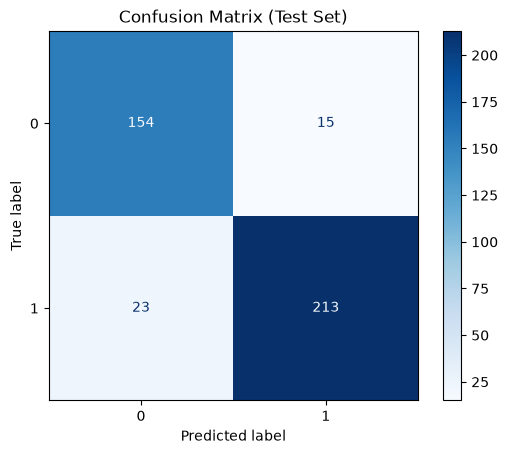

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.show()

##Decision Tree visualization

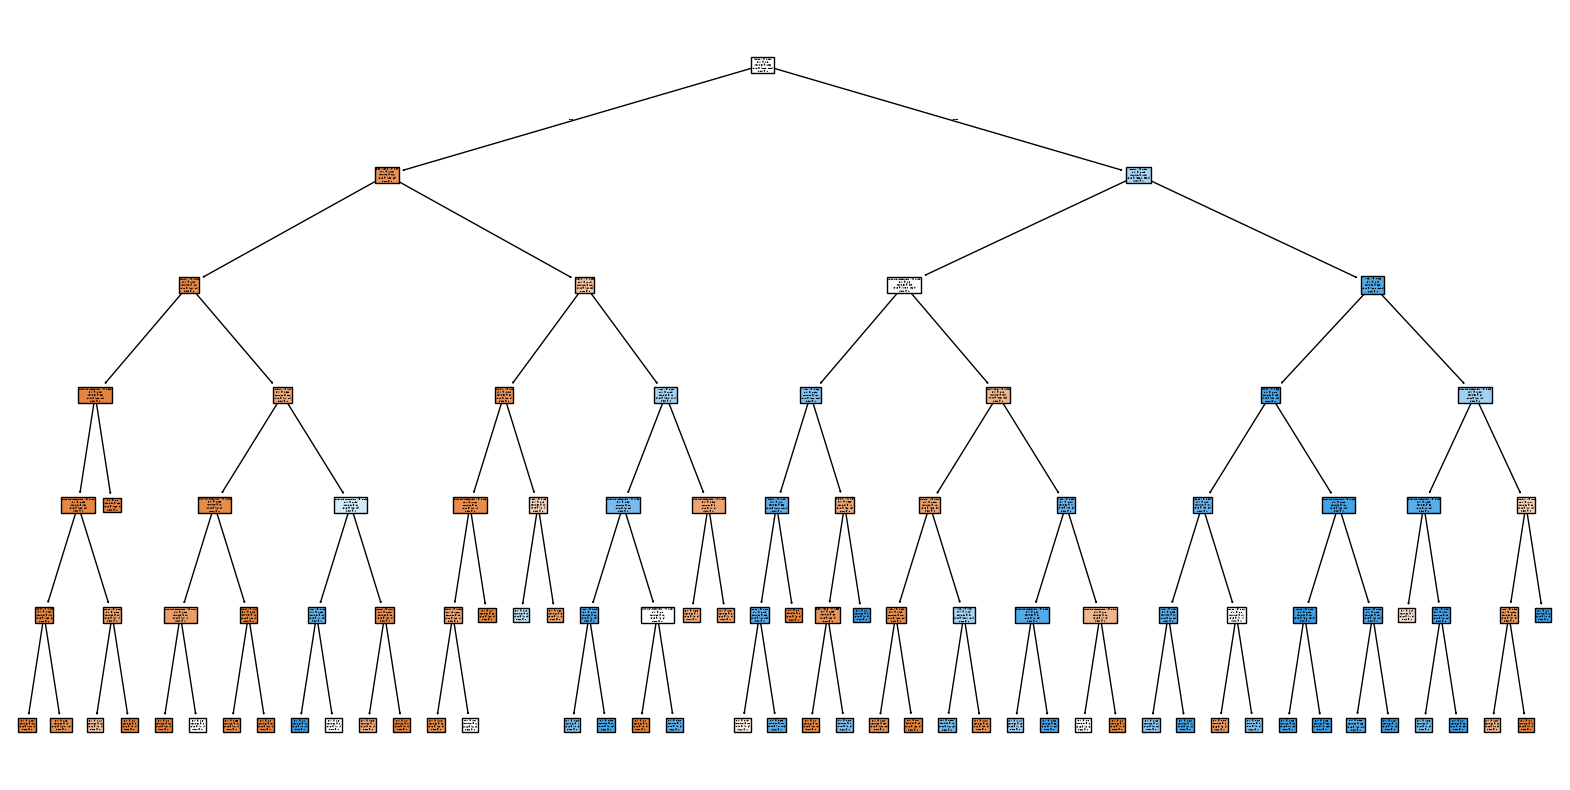

In [47]:
from sklearn import tree
import matplotlib.pyplot as plt

V_model = DecisionTreeClassifier(max_depth=5, min_samples_split = 10,random_state=42)

plt.figure(figsize=(20,10))
tree.plot_tree(model,
               filled=True,
               feature_names=X_train_selected.columns,
               class_names=['0', '1'])
plt.savefig("full_decision_tree.png", dpi=300)
plt.show()


- Best Model declaraion:  DecisionTreeClassifier(max_depth= 6, max_features= None, min_samples_leaf= 4, min_samples_split= 2)

# [3] Logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegression

selected_features = ['UPDRS','FunctionalAssessment','Tremor', 'MoCA', 'Bradykinesia','Rigidity']
X_train_selected = X_train_smote[selected_features]
X_test_selected = X_test[selected_features]


## Experiment with Regularization Parameter (C)

- C: It is the inverse of the regularization parameter λ (lambda),
and it determines strength of regularization in Logistic Regression.

C Value    Train Accuracy  Test Accuracy  
----------------------------------------
0.01       0.7879          0.7852         
0.1        0.7904          0.8000         
1          0.7933          0.8025         
10         0.7938          0.8000         
100        0.7943          0.8000         

Best C Value: 1
Best Test Accuracy: 0.8025


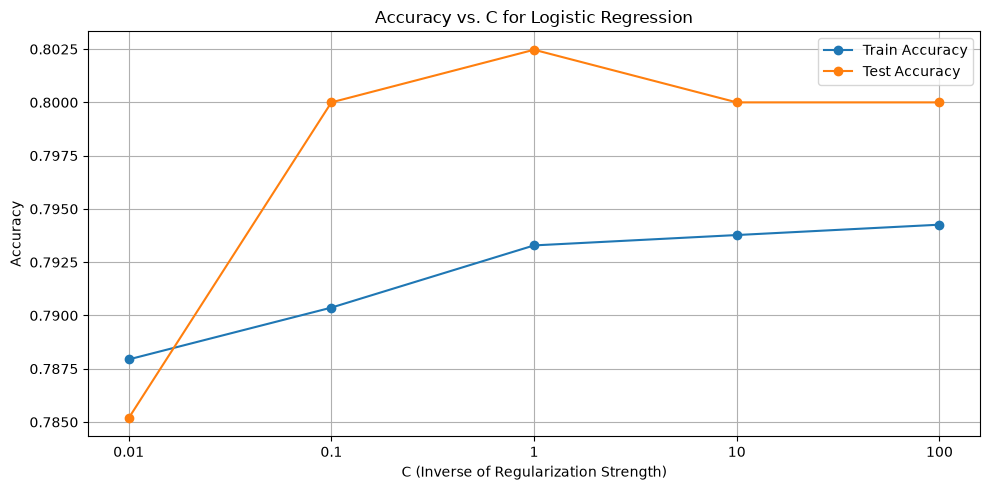

In [49]:
C_values = [0.01, 0.1, 1, 10, 100]

print(f"{'C Value':<10} {'Train Accuracy':<15} {'Test Accuracy':<15}")
print("-" * 40)

train_accuracy = []
test_accuracy = []
best_c = None
best_test_acc = -1

for C in C_values:
    model = LogisticRegression(C=C, solver='liblinear', max_iter=1000, random_state=42)
    model.fit(X_train_selected, y_train_smote)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    acc_train = accuracy_score(y_train_smote, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    train_accuracy.append(acc_train)
    test_accuracy.append(acc_test)

    print(f"{C:<10} {acc_train:<15.4f} {acc_test:<15.4f}")

    # Track the best C based on test accuracy
    if acc_test > best_test_acc:
        best_test_acc = acc_test
        best_c = C


print("\nBest C Value:", best_c)
print(f"Best Test Accuracy: {best_test_acc:.4f}")

plt.figure(figsize=(10, 5))
plt.plot([str(c) for c in C_values], train_accuracy, label="Train Accuracy", marker='o')
plt.plot([str(c) for c in C_values], test_accuracy, label="Test Accuracy", marker='o')
plt.xlabel("C (Inverse of Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. C for Logistic Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Hyperparameter tuning using grid search

In [50]:
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(random_state=42, max_iter=1000)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_selected, y_train_smote)

# Best parameters and model
best_params = grid_search.best_params_
print("\nBest Hyperparameters:", best_params)

best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(X_train_selected)
y_pred_test = best_model.predict(X_test_selected)

acc_train = accuracy_score(y_train_smote, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Average Validation Accuracy: {grid_search.best_score_:.4f}")
print(f"Train Accuracy: {acc_train:.4f}")
print(f"Test Accuracy: {acc_test:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Average Validation Accuracy: 0.7943
Train Accuracy: 0.7947
Test Accuracy: 0.7975


In [51]:
model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear', max_iter=1000, random_state=42)
start_fit_time_LR = time.time()
model.fit(X_train_selected, y_train_smote)
end_fit_time_LR = time.time()
LR_training_time = end_fit_time_LR - start_fit_time_LR
print(f"\n Total Logistic Regression Training Time: {LR_training_time:.4f} seconds")

start_test_LR = time.time()
y_pred = model.predict(X_test_selected)
end_test_LR = time.time()
LR_testing_time = end_test_LR - start_test_LR
print(f"\n Total Logistic Regression Test Time: {LR_testing_time:.4f} seconds")


 Total Logistic Regression Training Time: 0.0023 seconds

 Total Logistic Regression Test Time: 0.0000 seconds


## Model Evaluation

In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       169
           1       0.87      0.77      0.82       236

    accuracy                           0.80       405
   macro avg       0.79      0.80      0.80       405
weighted avg       0.81      0.80      0.80       405



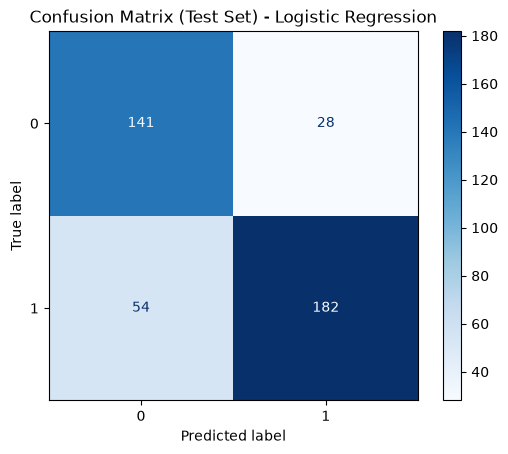

In [53]:
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set) - Logistic Regression')
plt.show()

- Best Model declaration: Logistic Regression(C: 0.1, penalty: 'l2', solver: 'liblinear')

#[4] SVM

### Tuning hyper paramters
- **`kernel`**: Specifies the type of decision function; options include `'linear'`, `'poly'`, `'rbf'`, `'sigmoid'`, etc.
- **`C`**: Regularization parameter; higher `C` means less regularization and a closer fit to the training data.
- **`gamma`**: Defines how far the influence of a single data point reaches; higher `gamma` means closer, tighter influence (risk of overfitting).



In [54]:
X_train = X_train_smote[['UPDRS','FunctionalAssessment','Tremor', 'MoCA', 'Bradykinesia','Rigidity']]
y_train = y_train_smote

X_test = X_test[['UPDRS','FunctionalAssessment','Tremor', 'MoCA', 'Bradykinesia','Rigidity']]
y_test

# X_train = X_train_smote['UPDRS']
# y_train = y_train_smote

# X_test = X_test['UPDRS']
# y_test

# Ensure inputs are 2D
if isinstance(X_train, pd.Series):
    X_train = X_train.to_frame()
if isinstance(X_test, pd.Series):
    X_test = X_test.to_frame()


In [55]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
C_list = [0.005,0.012,0.2,0.1, 1, 2, 10,15, 20,25, 50, 100, 200, 300, 500, 700, 800, 900, 1000]
gamma_list = ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10, 50, 60,75, 80, 90,100,150,200,250, 300, 400,500]
kernel_list = ['linear', 'poly', 'rbf', 'sigmoid']

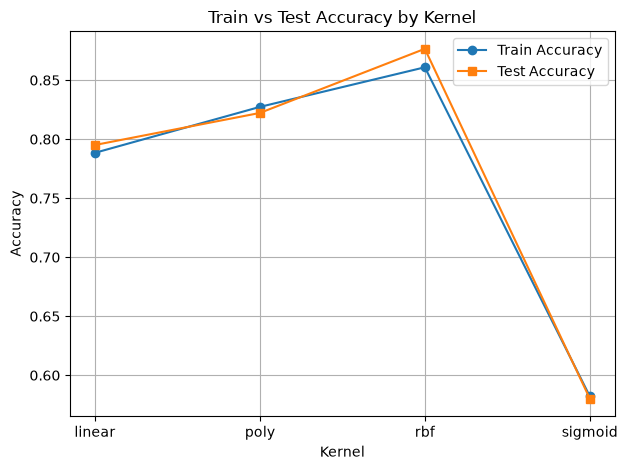

In [56]:
# First hyper parameter kernel

error_list_train = []
error_list_val = []

for kernel in kernel_list:
    model = SVC(kernel=kernel).fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    acc_train = accuracy_score(y_train, predictions_train)
    acc_val = accuracy_score(y_test, predictions_val)

    error_list_train.append(acc_train)
    error_list_val.append(acc_val)

plt.title('Train vs Test Accuracy by Kernel')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(kernel_list)), labels=kernel_list)
plt.plot(error_list_train, marker='o')
plt.plot(error_list_val, marker='s')
plt.legend(['Train Accuracy', 'Test Accuracy'])
plt.grid(True)
plt.tight_layout()
plt.show()


* we will choose rbf for kernel

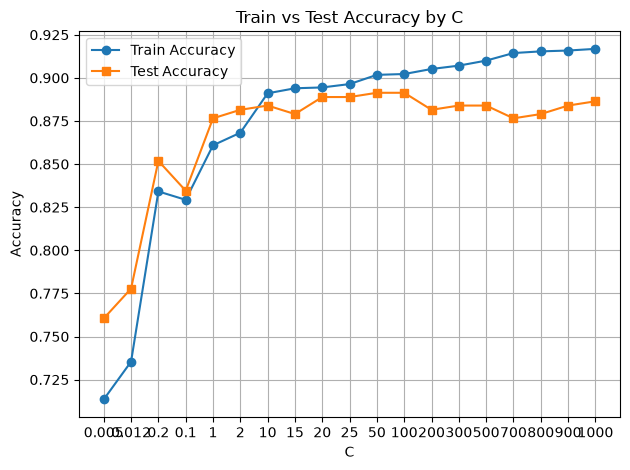

In [57]:
# Second hyper parameter  C

error_list_train = []
error_list_val = []

for C in C_list:
    model = SVC(kernel='rbf', C = C).fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    acc_train = accuracy_score(y_train, predictions_train)
    acc_val = accuracy_score(y_test, predictions_val)

    error_list_train.append(acc_train)
    error_list_val.append(acc_val)

plt.title('Train vs Test Accuracy by C')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(C_list)), labels=C_list)
plt.plot(error_list_train, marker='o')
plt.plot(error_list_val, marker='s')
plt.legend(['Train Accuracy', 'Test Accuracy'])
plt.grid(True)
plt.tight_layout()
plt.show()


* we chose C to be 15

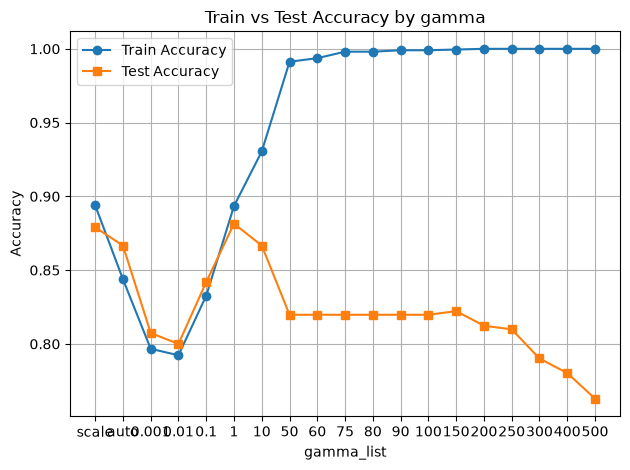

In [58]:
# Third hyper parameter gamma

error_list_train = []
error_list_val = []

for gamma in gamma_list:
    model = SVC(kernel='rbf', C = 15,gamma = gamma).fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    acc_train = accuracy_score(y_train, predictions_train)
    acc_val = accuracy_score(y_test, predictions_val)

    error_list_train.append(acc_train)
    error_list_val.append(acc_val)

plt.title('Train vs Test Accuracy by gamma')
plt.xlabel('gamma_list')
plt.ylabel('Accuracy')
plt.xticks(ticks=range(len(gamma_list)), labels=gamma_list)
plt.plot(error_list_train, marker='o')
plt.plot(error_list_val, marker='s')
plt.legend(['Train Accuracy', 'Test Accuracy'])
plt.grid(True)
plt.tight_layout()
plt.show()


* we choose gamma to be 1


## Cross Validation

Cross-Validation Accuracy:
Accuracy: 0.8726

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1028
           1       0.87      0.87      0.87      1028

    accuracy                           0.87      2056
   macro avg       0.87      0.87      0.87      2056
weighted avg       0.87      0.87      0.87      2056



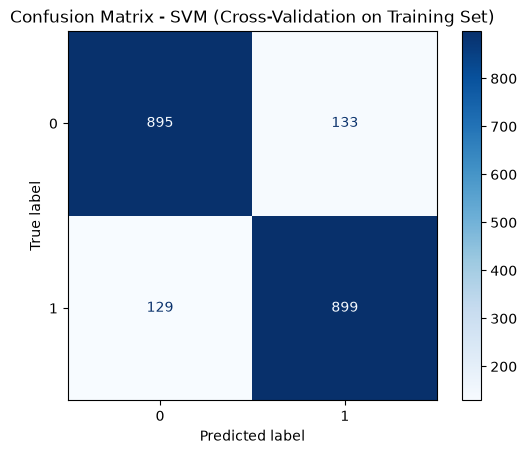

In [59]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=15, gamma=1)

y_pred = cross_val_predict(svm_model, X_train, y_train, cv=7)

accuracy = accuracy_score(y_train, y_pred)
print("Cross-Validation Accuracy:")
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_train, y_pred))

cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - SVM (Cross-Validation on Training Set)')
plt.show()


Total Training (Cross-Validation): 0.11 seconds

Total Testing : 0.05 seconds


Metrics - Test:
	Accuracy: 0.88
	Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       169
           1       0.91      0.89      0.90       236

    accuracy                           0.88       405
   macro avg       0.88      0.88      0.88       405
weighted avg       0.88      0.88      0.88       405

	Confusion Matrix:


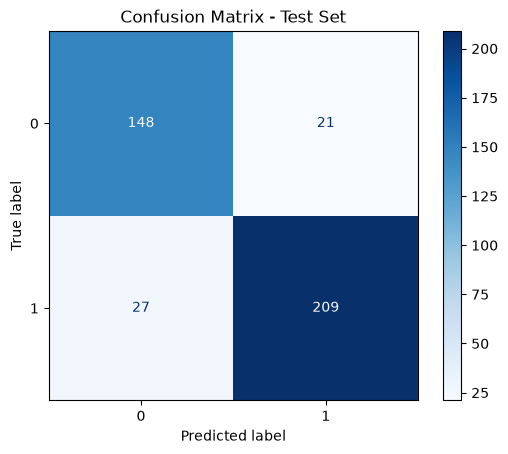

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

start_time = time.time()
svm_model.fit(X_train, y_train)
end_time = time.time()
svm_training_time = end_time - start_time
print(f"Total Training (Cross-Validation): {svm_training_time:.2f} seconds\n")

start_time = time.time()
y_pred = svm_model.predict(X_test)
end_time = time.time()
svm_testing_time = end_time - start_time
print(f"Total Testing : {svm_testing_time:.2f} seconds\n")

y_pred_train = svm_model.predict(X_train)

print("\nMetrics - Test:")
print(f"\tAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\tClassification Report:")
print(classification_report(y_test, y_pred))
print("\tConfusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred)

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])  # adjust labels as needed
disp_test.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()


## GridSearchCV

In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_model = SVC()

grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, n_jobs=4, scoring='accuracy')

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informa

In [62]:
print("Mean cross-validation scores:")
means=grid_search.cv_results_['mean_test_score']
params=grid_search.cv_results_['params']

for mean_score, param in zip(means, params):
 print(f"{mean_score:.3f} for {param}")

Mean cross-validation scores:
0.769 for {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
0.715 for {'C': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
0.769 for {'C': 0.01, 'gamma': 'auto', 'kernel': 'linear'}
0.731 for {'C': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}
0.769 for {'C': 0.01, 'gamma': 0.001, 'kernel': 'linear'}
0.532 for {'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}
0.769 for {'C': 0.01, 'gamma': 0.01, 'kernel': 'linear'}
0.532 for {'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
0.769 for {'C': 0.01, 'gamma': 0.1, 'kernel': 'linear'}
0.621 for {'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}
0.769 for {'C': 0.01, 'gamma': 1, 'kernel': 'linear'}
0.718 for {'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}
0.769 for {'C': 0.01, 'gamma': 10, 'kernel': 'linear'}
0.540 for {'C': 0.01, 'gamma': 10, 'kernel': 'rbf'}
0.788 for {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
0.821 for {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
0.788 for {'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}
0.799 for {'C': 0.1,

In [63]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'C': 50, 'gamma': 1, 'kernel': 'rbf'}
Best Score: 0.8725627760848511


Metrics - Train:
	Accuracy: 0.93
	Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1028
           1       0.93      0.92      0.92      1028

    accuracy                           0.93      2056
   macro avg       0.93      0.93      0.93      2056
weighted avg       0.93      0.93      0.93      2056

	Confusion Matrix:


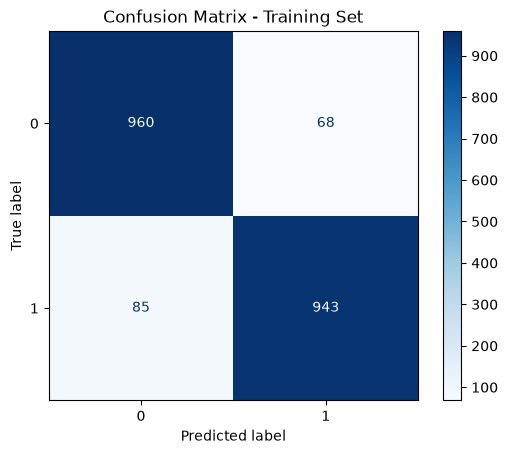


Metrics - Test:
	Accuracy: 0.87
	Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       169
           1       0.91      0.87      0.89       236

    accuracy                           0.87       405
   macro avg       0.87      0.87      0.87       405
weighted avg       0.87      0.87      0.87       405

	Confusion Matrix:


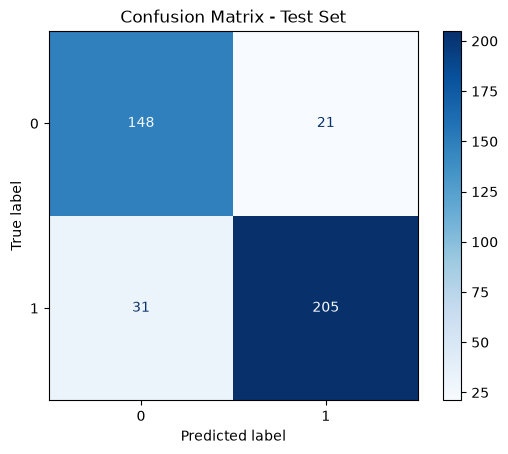

In [64]:
svm_model = SVC(kernel='rbf', C=10, gamma=10)

svm_model.fit(X_train, y_train)

y_pred_train = svm_model.predict(X_train)

y_pred = svm_model.predict(X_test)

print("Metrics - Train:")
print(f"\tAccuracy: {accuracy_score(y_train, y_pred_train):.2f}")
print("\tClassification Report:")
print(classification_report(y_train, y_pred_train))
print("\tConfusion Matrix:")
cm_train = confusion_matrix(y_train, y_pred_train)

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])  # adjust labels as needed
disp_train.plot(cmap='Blues')
plt.title('Confusion Matrix - Training Set')
plt.show()

print("\nMetrics - Test:")
print(f"\tAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\tClassification Report:")
print(classification_report(y_test, y_pred))
print("\tConfusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred)

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])  # adjust labels as needed
disp_test.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

## Performance Evaluation

## Accuracy Comparison Table for SVM

| Method                  | Feature Set     | Train Accuracy (%) | Test Accuracy (%) |
|------------------------|-----------------|---------------------|--------------------|
| Cross-Validation (CV)  | Top 1 Feature        | 70                  | 75                 |
| GridSearchCV           | Top 1 Feature        | 70                  | 73                 |
| Cross-Validation (CV)  | Top 6 Features   | 87                  | 89                 |
| GridSearchCV           | Top 6 Features   | 92                  | 86                 |

---




- Best Model declaraion: SVC(kernel='rbf', C=15, gamma=1)

# Overview of results

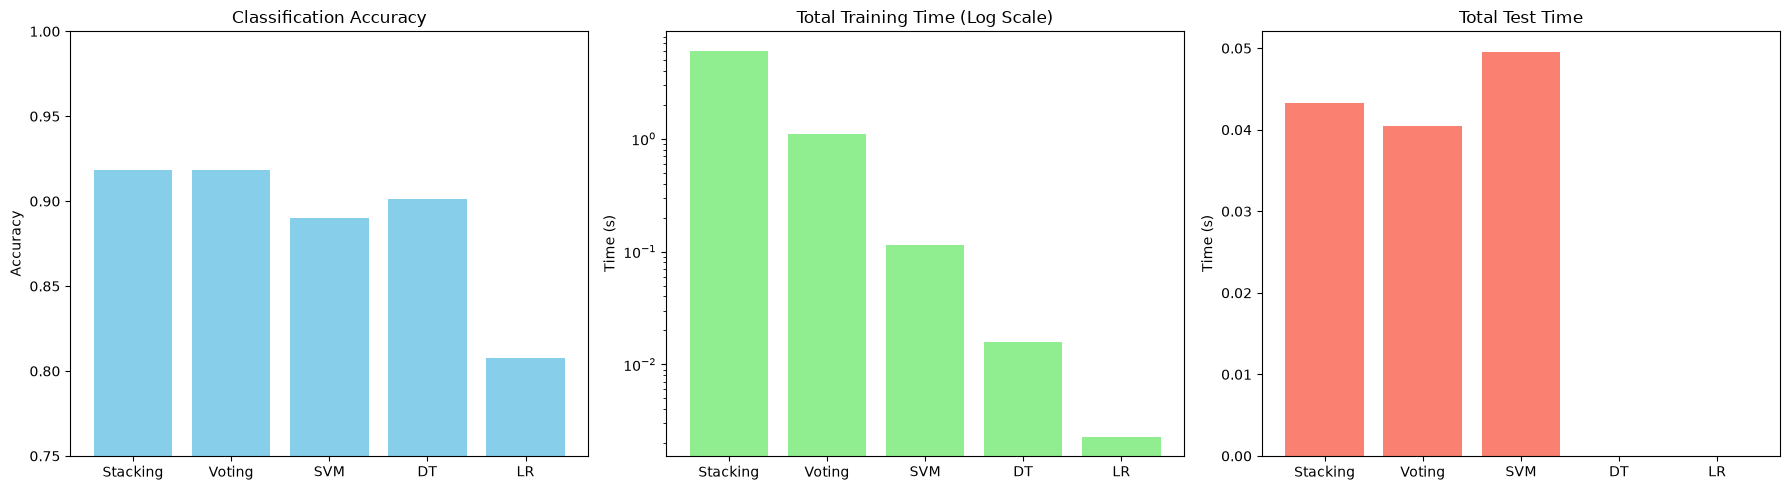

In [65]:
models = [ 'Stacking', 'Voting','SVM', 'DT', 'LR']
accuracy = [0.9185,0.9185,0.89, 0.9012, 0.8074]
train_time = [stack_train_time,Vote_train_time, svm_training_time,DT_training_time, LR_training_time]
test_time = [stack_test_time,Voting_test_time, svm_testing_time,DT_testing_time, LR_testing_time]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(models, accuracy, color='skyblue')
axes[0].set_title('Classification Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.75, 1])

axes[1].bar(models, train_time, color='lightgreen')
axes[1].set_yscale('log')
axes[1].set_title('Total Training Time (Log Scale)')
axes[1].set_ylabel('Time (s)')

axes[2].bar(models, test_time, color='salmon')
axes[2].set_title('Total Test Time')
axes[2].set_ylabel('Time (s)')

plt.tight_layout()
plt.show()

#print(train_time)
#print(test_time)

# Conclusion

In [66]:
df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Training Time (s)': train_time,
    'Testing Time (s)': test_time
})

df_sorted = df.sort_values(by='Accuracy', ascending=False)

print(df_sorted.to_string(index=False))

best_model = df_sorted.iloc[0]
print(f"\n Best model based on accuracy: {best_model['Model']} (Accuracy: {best_model['Accuracy']})")

   Model  Accuracy  Training Time (s)  Testing Time (s)
Stacking    0.9185           6.032521          0.043228
  Voting    0.9185           1.102352          0.040451
      DT    0.9012           0.015739          0.000000
     SVM    0.8900           0.114964          0.049589
      LR    0.8074           0.002289          0.000000

 Best model based on accuracy: Stacking (Accuracy: 0.9185)


# Saving the model


In [67]:
UPDRS = data['UPDRS'].mean()
FunctionalAssessment = data['FunctionalAssessment'].mean()
Tremor = data['Tremor'].mode()[0]
MoCA = data['MoCA'].mean()
Bradykinesia = data['Bradykinesia'].mode()[0]
Rigidity = data['Rigidity'].mode()[0]
features_nulls = [['UPDRS', UPDRS], ['FunctionalAssessment', FunctionalAssessment], ['Tremor', Tremor], ['MoCA',MoCA], ['Bradykinesia',Bradykinesia],['Rigidity',Rigidity]]
features_nulls = dict((k, v) for k, v in features_nulls)
features_nulls

{'UPDRS': np.float64(101.51919044768249),
 'FunctionalAssessment': np.float64(4.990582901784846),
 'Tremor': 0,
 'MoCA': np.float64(15.027269778590977),
 'Bradykinesia': 0,
 'Rigidity': 0}

In [68]:
with open('preprocessing.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'top_6_features': top_6_features,
        'numerical_cols': numerical_cols,
        'features_nulls': features_nulls,
        'model': stacking_model
    }, f)

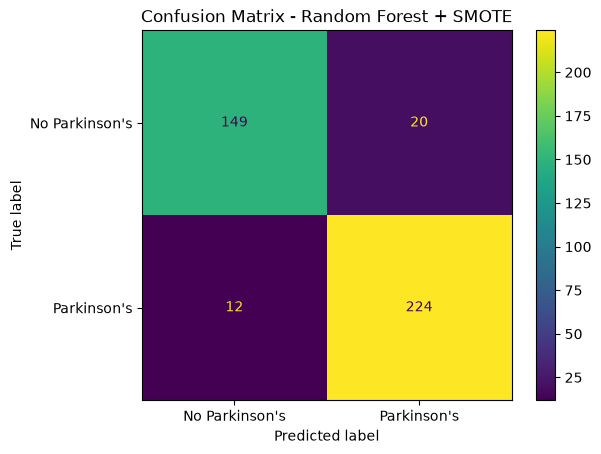

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Parkinson\'s', 'Parkinson\'s']
)

disp.plot()
plt.title("Confusion Matrix - Random Forest + SMOTE")
plt.show()

ROC-AUC Score: 0.9416934108915856


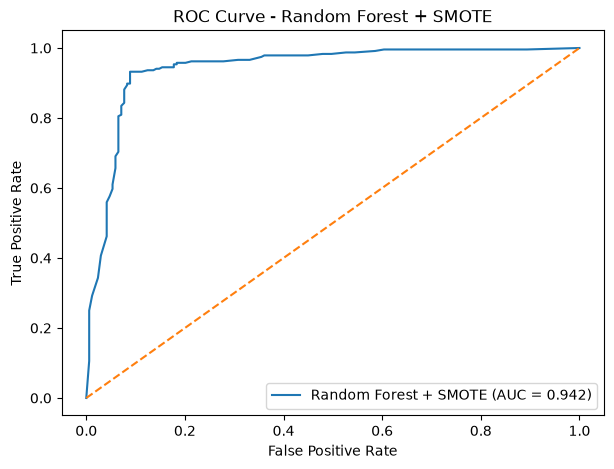

In [75]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Final 6 selected features
selected_features = [
    'UPDRS',
    'FunctionalAssessment',
    'Tremor',
    'MoCA',
    'Bradykinesia',
    'Rigidity'
]

# Prepare the exact train and test data
X_train_6 = X_train[selected_features]
X_test_6 = X_test[selected_features]

# Apply SMOTE only to training data
smote_roc = SMOTE(random_state=42)
X_train_6_smote, y_train_6_smote = smote_roc.fit_resample(
    X_train_6,
    y_train
)

# Train Random Forest
rf_roc = RandomForestClassifier(random_state=42)
rf_roc.fit(X_train_6_smote, y_train_6_smote)

# Probability predictions
y_prob_roc = rf_roc.predict_proba(X_test_6)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_roc)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_roc)

print("ROC-AUC Score:", roc_auc)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest + SMOTE (AUC = {roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest + SMOTE")
plt.legend()
plt.show()

In [77]:
selected_features = [
    'UPDRS',
    'FunctionalAssessment',
    'Tremor',
    'MoCA',
    'Bradykinesia',
    'Rigidity'
]

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print("Training shape:", X_train_selected.shape)
print("Testing shape:", X_test_selected.shape)

Training shape: (2056, 6)
Testing shape: (405, 6)


In [104]:
import os
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score


# ==========================================
# 1. Select the final 6 features
# ==========================================

selected_features = [
    'UPDRS',
    'FunctionalAssessment',
    'Tremor',
    'MoCA',
    'Bradykinesia',
    'Rigidity'
]

X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()


# ==========================================
# 2. Create scaler ONLY for these 6 features
# ==========================================

final_scaler = MinMaxScaler()

X_train_scaled = final_scaler.fit_transform(X_train_final)
X_test_scaled = final_scaler.transform(X_test_final)


# Convert back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=selected_features,
    index=X_train_final.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=selected_features,
    index=X_test_final.index
)


# ==========================================
# 3. Train final Random Forest
# ==========================================

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)

final_model.fit(X_train_scaled, y_train)


# ==========================================
# 4. Evaluate
# ==========================================

final_pred = final_model.predict(X_test_scaled)

final_prob = final_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, final_pred)
roc_auc = roc_auc_score(y_test, final_prob)

print("=" * 50)
print("FINAL RANDOM FOREST")
print("=" * 50)

print(classification_report(y_test, final_pred))

print("Test Accuracy:", accuracy)
print("Test ROC-AUC:", roc_auc)


# ==========================================
# 5. Create saved_model folder
# ==========================================

save_dir = os.path.join(os.getcwd(), "saved_model")
os.makedirs(save_dir, exist_ok=True)


# ==========================================
# 6. Save model, scaler and features
# ==========================================

joblib.dump(
    final_model,
    os.path.join(save_dir, "final_parkinsons_model.pkl")
)

joblib.dump(
    final_scaler,
    os.path.join(save_dir, "final_scaler.pkl")
)

joblib.dump(
    selected_features,
    os.path.join(save_dir, "final_selected_features.pkl")
)


# ==========================================
# 7. Verify
# ==========================================

print("\n" + "=" * 50)
print("FINAL MODEL SAVED SUCCESSFULLY!")
print("=" * 50)

print("\nSaved files:")

for file in os.listdir(save_dir):
    print(os.path.join(save_dir, file))

print("\nModel features:")
print(final_model.feature_names_in_)

print("\nScaler features:")
print(final_scaler.feature_names_in_)

FINAL RANDOM FOREST
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       169
           1       0.94      0.93      0.93       236

    accuracy                           0.92       405
   macro avg       0.92      0.92      0.92       405
weighted avg       0.92      0.92      0.92       405

Test Accuracy: 0.9209876543209876
Test ROC-AUC: 0.9439374185136897

FINAL MODEL SAVED SUCCESSFULLY!

Saved files:
c:\Users\HP\Desktop\Mini\Parkinson\Model Training\saved_model\final_parkinsons_model.pkl
c:\Users\HP\Desktop\Mini\Parkinson\Model Training\saved_model\final_scaler.pkl
c:\Users\HP\Desktop\Mini\Parkinson\Model Training\saved_model\final_selected_features.pkl

Model features:
['UPDRS' 'FunctionalAssessment' 'Tremor' 'MoCA' 'Bradykinesia' 'Rigidity']

Scaler features:
['UPDRS' 'FunctionalAssessment' 'Tremor' 'MoCA' 'Bradykinesia' 'Rigidity']


In [78]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_selected,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Diagnosis
0    1028
1    1028
Name: count, dtype: int64
After SMOTE: Diagnosis
0    1028
1    1028
Name: count, dtype: int64


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model_lr = LogisticRegression(max_iter=1000, random_state=42)

model_lr.fit(X_train_smote, y_train_smote)

lr_pred = model_lr.predict(X_test_selected)

print("Logistic Regression")
print(classification_report(y_test, lr_pred))
print("Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       169
           1       0.87      0.77      0.82       236

    accuracy                           0.80       405
   macro avg       0.79      0.80      0.80       405
weighted avg       0.81      0.80      0.80       405

Accuracy: 0.7975308641975308


In [80]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train_smote, y_train_smote)

rf_pred = model_rf.predict(X_test_selected)

print("Random Forest + SMOTE")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest + SMOTE
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       169
           1       0.94      0.93      0.93       236

    accuracy                           0.92       405
   macro avg       0.92      0.92      0.92       405
weighted avg       0.92      0.92      0.92       405

Accuracy: 0.9209876543209876


In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Decision Tree
model_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model_dt.fit(X_train_smote, y_train_smote)

dt_pred = model_dt.predict(X_test_selected)

print("Decision Tree + SMOTE")
print(classification_report(y_test, dt_pred))
print("Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree + SMOTE
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       169
           1       0.91      0.90      0.91       236

    accuracy                           0.89       405
   macro avg       0.89      0.89      0.89       405
weighted avg       0.89      0.89      0.89       405

Accuracy: 0.891358024691358


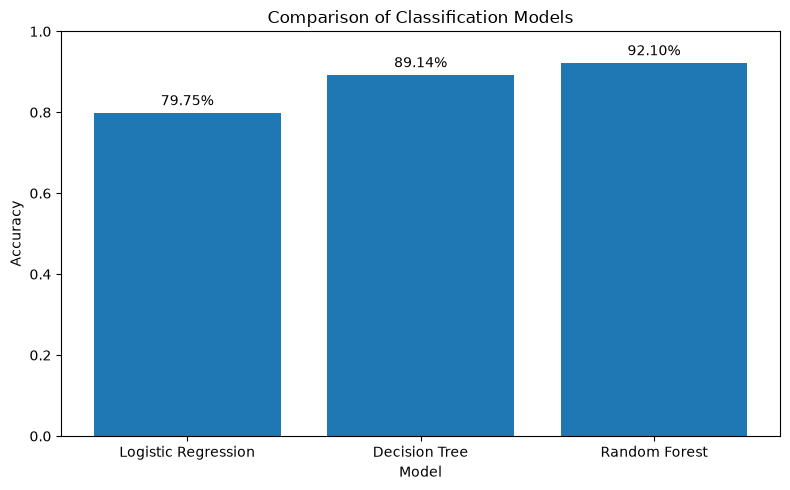

In [82]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Comparison of Classification Models")
plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.02,
        f"{acc:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [83]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 5-fold stratified cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_cv,
    X_train_selected,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation scores:
[0.89805825 0.90754258 0.91484185 0.89294404 0.87347932]

Mean CV Accuracy: 0.8973732076630526
Standard Deviation: 0.014139125152446365


In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_selected, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV Accuracy:
0.8988318805659887


In [85]:
# Get the best tuned Random Forest
best_rf = grid_search.best_estimator_

# Train/evaluate on the independent test set
best_rf_pred = best_rf.predict(X_test_selected)

print("Tuned Random Forest - Test Set")
print(classification_report(y_test, best_rf_pred))

print("Test Accuracy:",
      accuracy_score(y_test, best_rf_pred))

Tuned Random Forest - Test Set
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       169
           1       0.94      0.93      0.93       236

    accuracy                           0.92       405
   macro avg       0.92      0.92      0.92       405
weighted avg       0.92      0.92      0.92       405

Test Accuracy: 0.9209876543209876


In [86]:
from sklearn.metrics import roc_auc_score

best_rf_prob = best_rf.predict_proba(X_test_selected)[:, 1]

best_rf_auc = roc_auc_score(y_test, best_rf_prob)

print("Test ROC-AUC:", best_rf_auc)

Test ROC-AUC: 0.9439374185136897


In [87]:
import joblib
import os

# Create model folder
os.makedirs("saved_model", exist_ok=True)

# Save the tuned Random Forest model
joblib.dump(best_rf, "saved_model/parkinsons_random_forest.pkl")

# Save the scaler
joblib.dump(scaler, "saved_model/scaler.pkl")

# Save selected feature names
joblib.dump(selected_features, "saved_model/selected_features.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")
print("Selected features saved successfully!")

Model saved successfully!
Scaler saved successfully!
Selected features saved successfully!


In [88]:
import os

print(os.listdir("saved_model"))

['parkinsons_random_forest.pkl', 'scaler.pkl', 'selected_features.pkl']


In [89]:
import joblib

loaded_model = joblib.load(
    "saved_model/parkinsons_random_forest.pkl"
)

loaded_scaler = joblib.load(
    "saved_model/scaler.pkl"
)

loaded_features = joblib.load(
    "saved_model/selected_features.pkl"
)

print("Model loaded successfully!")
print("Number of selected features:", len(loaded_features))
print("Selected features:")
print(loaded_features)

Model loaded successfully!
Number of selected features: 6
Selected features:
['UPDRS', 'FunctionalAssessment', 'Tremor', 'MoCA', 'Bradykinesia', 'Rigidity']


In [90]:
import numpy as np
import pandas as pd

def predict_parkinsons(updrs, functional_assessment, tremor,
                       moca, bradykinesia, rigidity):

    input_data = pd.DataFrame([[
        updrs,
        functional_assessment,
        tremor,
        moca,
        bradykinesia,
        rigidity
    ]], columns=[
        'UPDRS',
        'FunctionalAssessment',
        'Tremor',
        'MoCA',
        'Bradykinesia',
        'Rigidity'
    ])

    prediction = best_rf.predict(input_data)
    probability = best_rf.predict_proba(input_data)[0]

    if prediction[0] == 1:
        result = "Parkinson's"
    else:
        result = "No Parkinson's"

    print("Prediction:", result)
    print("Probability of No Parkinson's:", round(probability[0] * 100, 2), "%")
    print("Probability of Parkinson's:", round(probability[1] * 100, 2), "%")

In [91]:
predict_parkinsons(
    updrs=35,
    functional_assessment=45,
    tremor=1,
    moca=20,
    bradykinesia=1,
    rigidity=1
)

Prediction: Parkinson's
Probability of No Parkinson's: 18.29 %
Probability of Parkinson's: 81.71 %


In [92]:
print("Selected features:")
print(selected_features)

print("\nScaler:")
print(scaler)

print("\nModel:")
print(best_rf)

Selected features:
['UPDRS', 'FunctionalAssessment', 'Tremor', 'MoCA', 'Bradykinesia', 'Rigidity']

Scaler:
MinMaxScaler()

Model:
RandomForestClassifier(min_samples_split=5, n_estimators=200, random_state=42)


In [93]:
print("Training data sample:")
print(X_train_selected.head())

print("\nTraining data ranges:")
print(X_train_selected.describe().loc[['min', 'max']])

Training data sample:
      UPDRS  FunctionalAssessment Tremor      MoCA Bradykinesia Rigidity
0  0.150093              0.739576    0.0  0.687539          0.0      1.0
1  0.237388              0.370671    1.0  0.126603          0.0      0.0
2  0.165311              0.606139    0.0  0.585283          0.0      0.0
3  0.216994              0.647271    0.0  0.785072          0.0      0.0
4  0.283916              0.914581    0.0  0.120552          0.0      0.0

Training data ranges:
     UPDRS  FunctionalAssessment  MoCA
min    0.0                   0.0   0.0
max    1.0                   1.0   1.0


In [94]:
print("Scaler features:")
print(scaler.feature_names_in_)

print("\nSelected features:")
print(selected_features)

Scaler features:
['Age' 'BMI' 'AlcoholConsumption' 'DietQuality' 'SleepQuality'
 'SystolicBP' 'DiastolicBP' 'CholesterolTotal' 'CholesterolLDL'
 'CholesterolHDL' 'CholesterolTriglycerides' 'UPDRS' 'MoCA'
 'FunctionalAssessment' 'WeeklyPhysicalActivity (hr)' 'EducationLevel_nan']

Selected features:
['UPDRS', 'FunctionalAssessment', 'Tremor', 'MoCA', 'Bradykinesia', 'Rigidity']


In [95]:
print("\nScaler minimum values:")
print(scaler.data_min_)

print("\nScaler maximum values:")
print(scaler.data_max_)


Scaler minimum values:
[5.00000000e+01 1.50083331e+01 2.22795540e-03 1.05381751e-05
 4.00049730e+00 9.00000000e+01 6.00000000e+01 1.50108315e+02
 5.01513186e+01 2.00279810e+01 5.01197133e+01 2.84410965e-02
 2.11912121e-02 1.50512317e-03 0.00000000e+00 0.00000000e+00]

Scaler maximum values:
[ 89.          39.99988684  19.98886597   9.99586431   9.999821
 179.         119.         299.96307393 199.98598067  99.98226535
 399.97502248 198.95360418  29.97010688   9.99269733 600.
   1.        ]


In [96]:
def preprocess_patient_input(updrs, functional_assessment, tremor,
                             moca, bradykinesia, rigidity):

    # Scale numerical features using the SAME scaler used during training
    updrs_scaled = (updrs - scaler.data_min_[11]) / (
        scaler.data_max_[11] - scaler.data_min_[11]
    )

    moca_scaled = (moca - scaler.data_min_[12]) / (
        scaler.data_max_[12] - scaler.data_min_[12]
    )

    functional_scaled = (functional_assessment - scaler.data_min_[13]) / (
        scaler.data_max_[13] - scaler.data_min_[13]
    )

    # Create input in exactly the same order as selected_features
    input_data = pd.DataFrame([[
        updrs_scaled,
        functional_scaled,
        tremor,
        moca_scaled,
        bradykinesia,
        rigidity
    ]], columns=selected_features)

    return input_data

In [97]:
def predict_parkinsons_final(updrs, functional_assessment, tremor,
                             moca, bradykinesia, rigidity):

    input_data = preprocess_patient_input(
        updrs,
        functional_assessment,
        tremor,
        moca,
        bradykinesia,
        rigidity
    )

    prediction = best_rf.predict(input_data)
    probability = best_rf.predict_proba(input_data)[0]

    if prediction[0] == 1:
        result = "Parkinson's"
    else:
        result = "No Parkinson's"

    print("Prediction:", result)
    print("Probability of No Parkinson's:",
          round(probability[0] * 100, 2), "%")
    print("Probability of Parkinson's:",
          round(probability[1] * 100, 2), "%")

In [98]:
predict_parkinsons_final(
    updrs=35,
    functional_assessment=45,
    tremor=1,
    moca=20,
    bradykinesia=1,
    rigidity=1
)

Prediction: Parkinson's
Probability of No Parkinson's: 47.7 %
Probability of Parkinson's: 52.3 %


In [99]:
import joblib
import os

# Create model directory
os.makedirs("saved_model", exist_ok=True)

# Save final tuned model
joblib.dump(best_rf, "saved_model/best_rf.pkl")

# Save scaler
joblib.dump(scaler, "saved_model/scaler.pkl")

# Save selected features
joblib.dump(selected_features, "saved_model/selected_features.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")
print("Selected features saved successfully!")

print("\nSaved files:")
print(os.listdir("saved_model"))

Model saved successfully!
Scaler saved successfully!
Selected features saved successfully!

Saved files:
['best_rf.pkl', 'parkinsons_random_forest.pkl', 'scaler.pkl', 'selected_features.pkl']


In [100]:
loaded_model = joblib.load("saved_model/best_rf.pkl")
loaded_scaler = joblib.load("saved_model/scaler.pkl")
loaded_features = joblib.load("saved_model/selected_features.pkl")

print("Model loaded:", type(loaded_model))
print("Scaler loaded:", type(loaded_scaler))
print("Features loaded:", loaded_features)

Model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Scaler loaded: <class 'sklearn.preprocessing._data.MinMaxScaler'>
Features loaded: ['UPDRS', 'FunctionalAssessment', 'Tremor', 'MoCA', 'Bradykinesia', 'Rigidity']


In [102]:
# ============================================================
# FINAL PARKINSON'S MODEL
# ============================================================

import os
import joblib
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# ------------------------------------------------------------
# 1. Selected features
# ------------------------------------------------------------

selected_features = [
    'UPDRS',
    'FunctionalAssessment',
    'Tremor',
    'MoCA',
    'Bradykinesia',
    'Rigidity'
]

print("Selected features:")
print(selected_features)


# ------------------------------------------------------------
# 2. Create training and testing datasets
# ------------------------------------------------------------

X_train_final = X_train[selected_features].copy()
X_test_final = X_test[selected_features].copy()

print("\nTraining shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)


# ------------------------------------------------------------
# 3. Convert required categorical/binary columns
# ------------------------------------------------------------

for df in [X_train_final, X_test_final]:

    for col in ['Tremor', 'Bradykinesia', 'Rigidity']:

        if df[col].dtype == 'object':

            df[col] = df[col].map({
                'Yes': 1,
                'No': 0
            })


# ------------------------------------------------------------
# 4. Make sure everything is numeric
# ------------------------------------------------------------

X_train_final = X_train_final.astype(float)
X_test_final = X_test_final.astype(float)


# ------------------------------------------------------------
# 5. Scale ONLY these 6 features
# ------------------------------------------------------------

final_scaler = MinMaxScaler()

X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_final_scaled = final_scaler.transform(X_test_final)


# ------------------------------------------------------------
# 6. Final Random Forest
# ------------------------------------------------------------

final_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    random_state=42
)

final_model.fit(
    X_train_final_scaled,
    y_train
)


# ------------------------------------------------------------
# 7. Test prediction
# ------------------------------------------------------------

final_pred = final_model.predict(X_test_final_scaled)

final_prob = final_model.predict_proba(
    X_test_final_scaled
)[:, 1]


# ------------------------------------------------------------
# 8. Evaluation
# ------------------------------------------------------------

print("\n======================================")
print("FINAL RANDOM FOREST")
print("======================================")

print(
    classification_report(
        y_test,
        final_pred
    )
)

print(
    "Test Accuracy:",
    accuracy_score(y_test, final_pred)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, final_prob)
)


# ------------------------------------------------------------
# 9. Create saved_model folder
# ------------------------------------------------------------

os.makedirs("saved_model", exist_ok=True)


# ------------------------------------------------------------
# 10. SAVE FINAL MODEL
# ------------------------------------------------------------

joblib.dump(
    final_model,
    "saved_model/final_parkinsons_model.pkl"
)

joblib.dump(
    final_scaler,
    "saved_model/final_scaler.pkl"
)

joblib.dump(
    selected_features,
    "saved_model/final_selected_features.pkl"
)


print("\n======================================")
print("FINAL MODEL SAVED SUCCESSFULLY!")
print("======================================")

print("\nSaved files:")

print("saved_model/final_parkinsons_model.pkl")
print("saved_model/final_scaler.pkl")
print("saved_model/final_selected_features.pkl")

Selected features:
['UPDRS', 'FunctionalAssessment', 'Tremor', 'MoCA', 'Bradykinesia', 'Rigidity']

Training shape: (2056, 6)
Testing shape: (405, 6)

FINAL RANDOM FOREST
              precision    recall  f1-score   support

           0       0.70      0.73      0.72       169
           1       0.80      0.78      0.79       236

    accuracy                           0.76       405
   macro avg       0.75      0.75      0.75       405
weighted avg       0.76      0.76      0.76       405

Test Accuracy: 0.7580246913580246
Test ROC-AUC: 0.8554808945943235

FINAL MODEL SAVED SUCCESSFULLY!

Saved files:
saved_model/final_parkinsons_model.pkl
saved_model/final_scaler.pkl
saved_model/final_selected_features.pkl


In [103]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders:")
print(os.listdir())

print("\nSaved model folder:")
if os.path.exists("saved_model"):
    print(os.listdir("saved_model"))
else:
    print("saved_model folder NOT FOUND")

Current working directory:
c:\Users\HP\Desktop\Mini\Parkinson\Model Training

Files/folders:
['Classification.ipynb', 'full_decision_tree.png', 'preprocessing.pkl', 'Regression.ipynb', 'saved_model']

Saved model folder:
['final_parkinsons_model.pkl', 'final_scaler.pkl', 'final_selected_features.pkl']
